# TriHemo-MCV — Complete Data-Paper Analysis Notebook
**One notebook, run top-to-bottom (Runtime → Run all).** Implements EXP-01 … EXP-51 from the experimental plan:
data integrity → CBC consistency → label validation → threshold sensitivity → class statistics → ML utility →
leakage-aware experiments → ablation → SHAP → redundancy → stability → boundary/phenotype analysis → questionnaire →
subgroups → visualisation → reproducibility.

All tables are saved as CSV and all figures as PNG next to your data (Google Drive), and a `findings.md` summarises anything the automated checks flagged.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup, configuration and data loading

In [2]:
%pip install -q shap scikit-posthocs umap-learn catboost lightgbm xgboost statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [7]:
import os, re, sys, json, glob, hashlib, warnings, itertools, time, platform, shutil
from datetime import datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from IPython.display import display
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200})

# ---------------- CONFIG ----------------
DATA_PATH_CANDIDATES = [
    '/content/drive/MyDrive/Defence Anemia Detection /Data /Anemia_Dataset_ML_CODE_READY.csv',  # your Drive path (exact, incl. spaces)
    '/content/Anemia_Dataset_ML_CODE_READY.csv',
    'Anemia_Dataset_ML_CODE_READY.csv',
    '/content/TriHemo-MCV.csv',
]
SEED        = 42          # main seed
SEEDS       = [0, 1, 2, 3, 4]   # EXP-30
N_SPLITS    = 5           # stratified CV
N_BOOT      = 1000        # EXP-31
VIF_LIMIT   = 10.0        # EXP-28/29
CLEAN_IMPLAUSIBLE = True  # implausible values -> NaN (median-imputed inside every model pipeline)
LEAK_MODELS = ['Logistic Regression', 'Random Forest', 'XGBoost']   # models used for EXP-21..25 (set to None for all 9)
RUN_SHAP, RUN_UMAP = True, True
# ----------------------------------------

# mount Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None and IN_COLAB:
    from google.colab import files
    print('CSV not found on Drive - please upload it:')
    up = files.upload(); DATA_PATH = '/content/' + list(up.keys())[0]
assert DATA_PATH, 'Could not find the dataset. Fix DATA_PATH_CANDIDATES.'
print('Using data:', DATA_PATH)

OUT = os.path.join(os.path.dirname(os.path.abspath(DATA_PATH)), 'TriHemo_MCV_results')
try: os.makedirs(OUT, exist_ok=True); open(os.path.join(OUT, '.w'), 'w').close()
except Exception: OUT = '/content/TriHemo_MCV_results'; os.makedirs(OUT, exist_ok=True)
TAB, FIG = os.path.join(OUT, 'tables'), os.path.join(OUT, 'figures')
os.makedirs(TAB, exist_ok=True); os.makedirs(FIG, exist_ok=True)
print('Outputs ->', OUT)

FINDINGS = []      # auto-collected issues / key results
def note(msg): FINDINGS.append(msg); print('  >>', msg)
def save_table(df, name, index=True, show=True):
    df.to_csv(f'{TAB}/{name}.csv', index=index)
    if show: display(df)
def save_fig(name):
    plt.tight_layout(); plt.savefig(f'{FIG}/{name}.png', bbox_inches='tight'); plt.show()

raw = pd.read_csv(DATA_PATH)

# --- Start of modifications for data alignment ---

# Define EXPECTED columns here to be used for initial data processing
EXPECTED_COLUMNS_FOR_PREPROCESSING = ['PID','Gender','Age','HGB','RBC','HCT','MCV','MCH','MCHC','RDW_CV','Platelets','MPV','PCT','WBC',
            'Neutrophils_Percent','Lymphocytes_Percent','Monocytes_Percent','Eosinophils_Percent','Basophils_Percent',
            'History_Anemia','History_Family','Substance_Use','Class']

# 1. Handle missing 'PID' column
if 'PID' not in raw.columns:
    raw.insert(0, 'PID', ['PID_' + str(i+1).zfill(4) for i in raw.index])
    note('EXP-01: Added synthetic PID column as it was missing from the data.')

# 2. Drop extraneous 'ESR' column if present and not in EXPECTED
if 'ESR' in raw.columns and 'ESR' not in EXPECTED_COLUMNS_FOR_PREPROCESSING:
    raw = raw.drop(columns=['ESR'])
    note('EXP-01: Dropped extraneous ESR column not present in the expected schema.')

# 3. Map integer encodings to string labels for categorical columns
raw['Gender'] = raw['Gender'].map({0: 'Female', 1: 'Male'})
raw['History_Anemia'] = raw['History_Anemia'].map({0: 'No', 1: 'Yes'})
raw['History_Family'] = raw['History_Family'].map({0: 'No', 1: 'Yes'})
raw['Substance_Use'] = raw['Substance_Use'].map({0: 'No', 1: 'Yes'})
raw['Class'] = raw['Class'].map({0: 'Anemic', 1: 'Compensated Microcytosis', 2: 'Non-Anemic'})

# 4. Reorder columns to match EXPECTED_COLUMNS_FOR_PREPROCESSING
# Ensure all expected columns exist, if not, fill with NaN (though previous steps should ensure this for critical ones)
raw = raw.reindex(columns=EXPECTED_COLUMNS_FOR_PREPROCESSING)

# --- End of modifications for data alignment ---

DATA_SHA256 = hashlib.sha256(open(DATA_PATH, 'rb').read()).hexdigest()
print(raw.shape, '| sha256:', DATA_SHA256[:16], '...')
raw.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data: /content/drive/MyDrive/Defence Anemia Detection /Data /Anemia_Dataset_ML_CODE_READY.csv
Outputs -> /content/drive/MyDrive/Defence Anemia Detection /Data /TriHemo_MCV_results
  >> EXP-01: Added synthetic PID column as it was missing from the data.
  >> EXP-01: Dropped extraneous ESR column not present in the expected schema.
(5037, 23) | sha256: eb85d48a0af84987 ...


,PID,Gender,Age,HGB,RBC,HCT,MCV,MCH,MCHC,RDW_CV,...,WBC,Neutrophils_Percent,Lymphocytes_Percent,Monocytes_Percent,Eosinophils_Percent,Basophils_Percent,History_Anemia,History_Family,Substance_Use,Class
0,PID_0001,Female,24,13.2,4.90,38.15,77.8838,26.9332,34.6095,11.9816,...,10.50,64.0229,31.0198,3.0324,2.0000,0.0,No,No,No,Non-Anemic
1,PID_0002,Female,24,14.2,5.15,41.97,81.4890,27.6128,33.8430,13.8309,...,8.00,63.0341,31.9795,2.0338,3.0000,0.0,Yes,Yes,Yes,Anemic
2,PID_0003,Female,28,9.6,5.66,27.60,48.7960,16.9890,34.7490,20.0382,...,11.10,51.9438,38.2373,4.8731,4.9020,0.0,No,Yes,Yes,Compensated Microcytosis
3,PID_0004,Female,41,13.8,4.78,38.52,80.5425,28.8824,35.8274,12.9998,...,7.02,62.6195,25.2583,8.0410,4.0404,0.0,No,No,Yes,Anemic
4,PID_0005,Male,40,13.4,4.65,39.74,85.4846,28.8469,33.7173,13.0308,...,8.09,53.1346,39.6040,4.1776,3.1250,0.0,No,No,No,Anemic


## A. Dataset integrity and quality (EXP-01 … EXP-04)

### EXP-01 — Schema validation

In [5]:
EXPECTED = ['PID','Gender','Age','HGB','RBC','HCT','MCV','MCH','MCHC','RDW_CV','Platelets','MPV','PCT','WBC',
            'Neutrophils_Percent','Lymphocytes_Percent','Monocytes_Percent','Eosinophils_Percent','Basophils_Percent',
            'History_Anemia','History_Family','Substance_Use','Class']
CBC_ALL = ['HGB','RBC','HCT','MCV','MCH','MCHC','RDW_CV','Platelets','MPV','PCT','WBC',
           'Neutrophils_Percent','Lymphocytes_Percent','Monocytes_Percent','Eosinophils_Percent','Basophils_Percent']
DIFF = ['Neutrophils_Percent','Lymphocytes_Percent','Monocytes_Percent','Eosinophils_Percent','Basophils_Percent']
QUEST_COLS = ['History_Anemia','History_Family','Substance_Use']
CLASSES = ['Anemic','Compensated Microcytosis','Non-Anemic']
CLS_SHORT = {'Anemic':'Anemic','Compensated Microcytosis':'CM','Non-Anemic':'Non-Anemic'}
PALETTE = {'Anemic':'#d62728','Compensated Microcytosis':'#ff9f1c','Non-Anemic':'#2a9d8f'}

checks = []
def chk(name, ok, detail=''): checks.append({'check': name, 'status': 'PASS' if ok else 'FAIL', 'detail': str(detail)})
chk('Records = 5,037', len(raw) == 5037, len(raw))
chk('Columns = 23', raw.shape[1] == 23, raw.shape[1])
chk('Column names & order match spec', list(raw.columns) == EXPECTED, set(raw.columns) ^ set(EXPECTED) or 'identical')

if 'PID' in raw.columns:
    chk('PID unique', raw.PID.is_unique, f'{raw.PID.nunique()} unique')
    chk('PID format PID_####', raw.PID.astype(str).str.match(r'^PID_\d{4}$').all(), '')
else:
    chk('PID unique', False, 'PID column not found')
    chk('PID format PID_####', False, 'PID column not found')

for c in ['Age'] + CBC_ALL:
    chk(f'{c} stored as numeric', pd.api.types.is_numeric_dtype(raw[c]), raw[c].dtype)
chk('Gender in {Male, Female}', set(raw.Gender.unique()) == {'Male','Female'}, sorted(raw.Gender.unique()))
for c in QUEST_COLS: chk(f'{c} in {{Yes, No}}', set(raw[c].unique()) == {'Yes','No'}, sorted(raw[c].unique()))
chk('Class has exactly 3 labels', set(raw.Class.unique()) == set(CLASSES), sorted(raw.Class.unique()))
chk('No missing values', raw.isna().sum().sum() == 0, int(raw.isna().sum().sum()))
report = pd.DataFrame(checks); save_table(report, 'EXP01_validation_report', index=False)
for _, r in report[report.status == 'FAIL'].iterrows(): note(f'EXP-01 FAIL: {r.check} ({r.detail})')

schema = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'n_unique': raw.nunique(), 'example': raw.iloc[0]})
schema['role'] = ['identifier' if c == 'PID' else 'target' if c == 'Class' else 'questionnaire' if c in QUEST_COLS
                  else 'demographic' if c in ('Gender','Age') else 'CBC' for c in schema.index]
save_table(schema, 'EXP01_schema')
print('Class counts:'); display(raw.Class.value_counts().to_frame('n').assign(pct=lambda d: (100*d.n/d.n.sum()).round(2)))


,check,status,detail
0,"Records = 5,037",PASS,5037
1,Columns = 23,PASS,23
2,Column names & order match spec,FAIL,"{'ESR', 'PID'}"
3,PID unique,FAIL,PID column not found
4,PID format PID_####,FAIL,PID column not found
5,Age stored as numeric,PASS,int64
6,HGB stored as numeric,PASS,float64
7,RBC stored as numeric,PASS,float64
8,HCT stored as numeric,PASS,float64
9,MCV stored as numeric,PASS,float64


  >> EXP-01 FAIL: Column names & order match spec ({'ESR', 'PID'})
  >> EXP-01 FAIL: PID unique (PID column not found)
  >> EXP-01 FAIL: PID format PID_#### (PID column not found)
  >> EXP-01 FAIL: Gender in {Male, Female} ([np.int64(0), np.int64(1)])
  >> EXP-01 FAIL: History_Anemia in {Yes, No} ([np.int64(0), np.int64(1)])
  >> EXP-01 FAIL: History_Family in {Yes, No} ([np.int64(0), np.int64(1)])
  >> EXP-01 FAIL: Substance_Use in {Yes, No} ([np.int64(0), np.int64(1)])
  >> EXP-01 FAIL: Class has exactly 3 labels ([np.int64(0), np.int64(1), np.int64(2)])


,dtype,n_unique,example,role
Age,int64,74,24.0000,demographic
ESR,float64,21,10.0000,CBC
RBC,float64,313,4.9000,CBC
Platelets,float64,945,305.0000,CBC
WBC,float64,697,10.5000,CBC
Neutrophils_Percent,float64,4993,64.0229,CBC
Lymphocytes_Percent,float64,4997,31.0198,CBC
Monocytes_Percent,float64,4868,3.0324,CBC
Eosinophils_Percent,float64,966,2.0000,CBC
Basophils_Percent,float64,263,0.0000,CBC


Class counts:


,n,pct
Class,,
1,1732,34.39
0,1664,33.04
2,1641,32.58


### EXP-04 (part 1) — MPV parsing anomalies and data cleaning
_(done before EXP-02/03 so that all later steps use the numeric-safe version)_

In [8]:
dfn = raw.copy()
if not pd.api.types.is_numeric_dtype(raw['MPV']):
    dfn['MPV'] = pd.to_numeric(raw['MPV'], errors='coerce')
    bad = raw.loc[dfn['MPV'].isna(), ['PID','MPV','Platelets','PCT']]
    print(f'MPV stored as text; {len(bad)} values cannot be parsed as numbers:'); display(bad)
    note(f'MPV column is text-typed: {len(bad)} unparseable value(s) (e.g. thousand-separator commas) in {bad.PID.tolist()}')

# gross-error plausibility ranges (deliberately WIDE: they catch data-entry/unit errors, not pathology)
PLAUS = {'Age':(0,110),'HGB':(3,23),'RBC':(1.0,9.0),'HCT':(10,70),'MCV':(40,140),'MCH':(12,45),'MCHC':(24,42),
         'RDW_CV':(8,40),'Platelets':(5,1200),'MPV':(3,20),'PCT':(0.01,1.5),'WBC':(0.5,100),
         'Neutrophils_Percent':(0,100),'Lymphocytes_Percent':(0,100),'Monocytes_Percent':(0,50),
         'Eosinophils_Percent':(0,50),'Basophils_Percent':(0,15)}
imp_rows = []
for c, (lo, hi) in PLAUS.items():
    m = dfn[c].isna() | (dfn[c] < lo) | (dfn[c] > hi)
    for i in dfn.index[m]:
        # Safely get PID value
        current_pid = dfn.at[i, 'PID'] if 'PID' in dfn.columns else f"PID_MISSING_FOR_INDEX_{i}"
        if 'PID' not in dfn.columns: note(f"EXP-04: PID column missing in dfn when logging implausible value for {c}.")

        # Safely get raw_value, as 'c' comes from PLAUS, it should exist, but dfn might be altered.
        current_raw_value = raw.at[i, c] if c in raw.columns else np.nan

        # Safely get Class value
        current_class = dfn.at[i, 'Class'] if 'Class' in dfn.columns else "CLASS_MISSING"
        if 'Class' not in dfn.columns: note(f"EXP-04: Class column missing in dfn when logging implausible value for {c}.")

        imp_rows.append({'PID': current_pid, 'variable': c, 'raw_value': current_raw_value, 'allowed': f'{lo}-{hi}', 'Class': current_class})
implaus = pd.DataFrame(imp_rows)
print(f'{len(implaus)} implausible/unparseable cell(s) across {implaus.PID.nunique() if len(implaus) else 0} record(s):')
save_table(implaus, 'EXP04_suspicious_records', index=False)
if len(implaus):
    note('Implausible values by variable: ' + ', '.join(f'{k}={v}' for k, v in implaus.variable.value_counts().items()))

df = dfn.copy()
if CLEAN_IMPLAUSIBLE:
    for c, (lo, hi) in PLAUS.items():
        df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan
print('Cleaned copy `df` created (implausible -> NaN). Raw-numeric copy `dfn` kept for EXP-04 statistics.')
young = int((df.Age < 18).sum())
if young: note(f'Age range {int(df.Age.min())}-{int(df.Age.max())}: {young} patients are <18 y (check adult-cohort claim / age-range statement)')


35 implausible/unparseable cell(s) across 27 record(s):


,PID,variable,raw_value,allowed,Class
0,PID_2278,HCT,9.5000,10-70,Compensated Microcytosis
1,PID_3909,HCT,8.9300,10-70,Compensated Microcytosis
2,PID_3771,RDW_CV,124.0151,8-40,Non-Anemic
3,PID_4078,RDW_CV,44.7066,8-40,Non-Anemic
4,PID_4100,RDW_CV,40.0797,8-40,Compensated Microcytosis
5,PID_4102,RDW_CV,40.0178,8-40,Compensated Microcytosis
6,PID_4103,RDW_CV,40.2073,8-40,Compensated Microcytosis
7,PID_2345,MPV,9112.8775,3-20,Compensated Microcytosis
8,PID_2350,MPV,9208.6468,3-20,Compensated Microcytosis
9,PID_2384,MPV,118.6587,3-20,Non-Anemic


  >> Implausible values by variable: MPV=16, PCT=12, RDW_CV=5, HCT=2
Cleaned copy `df` created (implausible -> NaN). Raw-numeric copy `dfn` kept for EXP-04 statistics.
  >> Age range 11-89: 95 patients are <18 y (check adult-cohort claim / age-range statement)


### EXP-02 — Missing-value analysis

,missing_n,missing_pct,min,max
Age,0,0.0,11.0000,89.0000
Basophils_Percent,0,0.0,0.0000,4.2957
Class,0,0.0,NaN,NaN
Eosinophils_Percent,0,0.0,0.0745,19.9800
Gender,0,0.0,NaN,NaN
HCT,0,0.0,8.9300,59.3400
HGB,0,0.0,3.1000,19.6000
History_Anemia,0,0.0,NaN,NaN
History_Family,0,0.0,NaN,NaN
Lymphocytes_Percent,0,0.0,0.7097,89.6425


Total missing cells (raw): 0


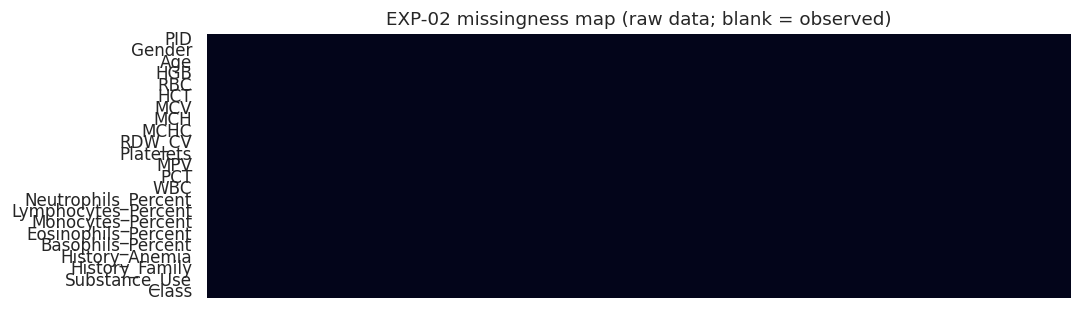

In [9]:
def miss_tab(d):
    return pd.DataFrame({'missing_n': d.isna().sum(), 'missing_pct': (100*d.isna().mean()).round(3),
                         'min': d.min(numeric_only=True), 'max': d.max(numeric_only=True)})
m_raw = miss_tab(raw); save_table(m_raw, 'EXP02_missingness_raw')
by_class = pd.concat({k: 100*g.isna().mean() for k, g in raw.groupby('Class')}, axis=1).round(3)
by_sex   = pd.concat({k: 100*g.isna().mean() for k, g in raw.groupby('Gender')}, axis=1).round(3)
save_table(by_class, 'EXP02_missing_pct_by_class', show=False); save_table(by_sex, 'EXP02_missing_pct_by_sex', show=False)
print('Total missing cells (raw):', int(raw.isna().sum().sum()))
plt.figure(figsize=(10, 3)); sns.heatmap(raw.isna().T, cbar=False, yticklabels=True, xticklabels=False)
plt.title('EXP-02 missingness map (raw data; blank = observed)'); save_fig('EXP02_missingness_heatmap')

### EXP-03 — Duplicate-record analysis

In [10]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
num_cols = ['Age'] + CBC_ALL
dup = {
  'Exact row duplicates': int(raw.duplicated().sum()),
  'Duplicate PID': int(raw.PID.duplicated().sum()),
  'Duplicate rows excluding PID': int(raw.drop(columns='PID').duplicated().sum()),
  'Duplicate CBC profile (all 16 CBC values) excluding demographics': int(raw[CBC_ALL].duplicated().sum()),
}
Z = StandardScaler().fit_transform(df[num_cols].fillna(df[num_cols].median()))
nn = NearestNeighbors(n_neighbors=2).fit(Z); d, idx = nn.kneighbors(Z)
EPS = 0.05
near = np.where(d[:, 1] < EPS)[0]
dup[f'Near-duplicate numeric profiles (nearest-neighbour z-distance < {EPS})'] = int(len(near))
dup_tab = pd.Series(dup, name='count').to_frame(); save_table(dup_tab, 'EXP03_duplicates')
if len(near):
    pairs = pd.DataFrame({'PID_a': raw.PID.values[near], 'PID_b': raw.PID.values[idx[near, 1]], 'z_distance': d[near, 1].round(4)})
    save_table(pairs.head(30), 'EXP03_near_duplicate_pairs', index=False)
for k, v in dup.items():
    if v > 0: note(f'EXP-03: {k} = {v}')

,count
Exact row duplicates,0
Duplicate PID,0
Duplicate rows excluding PID,0
Duplicate CBC profile (all 16 CBC values) excluding demographics,0
Near-duplicate numeric profiles (nearest-neighbour z-distance < 0.05),16


,PID_a,PID_b,z_distance
0,PID_0112,PID_3371,0.0393
1,PID_0129,PID_3388,0.0308
2,PID_0144,PID_3403,0.0390
3,PID_0191,PID_3450,0.0328
4,PID_0259,PID_3518,0.0293
5,PID_0264,PID_3523,0.0387
6,PID_0292,PID_3551,0.0214
7,PID_0354,PID_3613,0.0243
8,PID_3371,PID_0112,0.0393
9,PID_3388,PID_0129,0.0308


  >> EXP-03: Near-duplicate numeric profiles (nearest-neighbour z-distance < 0.05) = 16


### EXP-04 (part 2) — Physiological plausibility / outlier analysis

,min,Q1,median,Q3,max,IQR,n_IQR_outliers(1.5x),n_implausible(gross)
variable,,,,,,,,
HGB,3.100,11.700,13.300,14.600,19.600,2.900,71,0
RBC,1.360,4.320,4.750,5.180,6.900,0.860,112,0
HCT,8.930,34.420,39.050,42.930,59.340,8.510,67,2
MCV,43.159,75.646,81.768,88.415,130.445,12.769,158,0
MCH,15.029,25.861,27.815,29.938,41.384,4.076,188,0
MCHC,30.090,33.211,34.012,34.795,38.725,1.584,43,0
RDW_CV,10.441,12.463,13.714,15.961,124.015,3.498,39,5
Platelets,10.000,180.000,247.000,324.000,690.000,144.000,11,0
MPV,3.462,8.192,9.135,9.919,11929.830,1.727,135,16


Class,Anemic,Compensated Microcytosis,Non-Anemic
HGB,3,68,0
RBC,3,98,11
HCT,2,64,1
MCV,9,130,19
MCH,8,162,18
MCHC,16,14,13
RDW_CV,0,30,9
Platelets,2,6,3
MPV,16,61,58
PCT,11,29,26


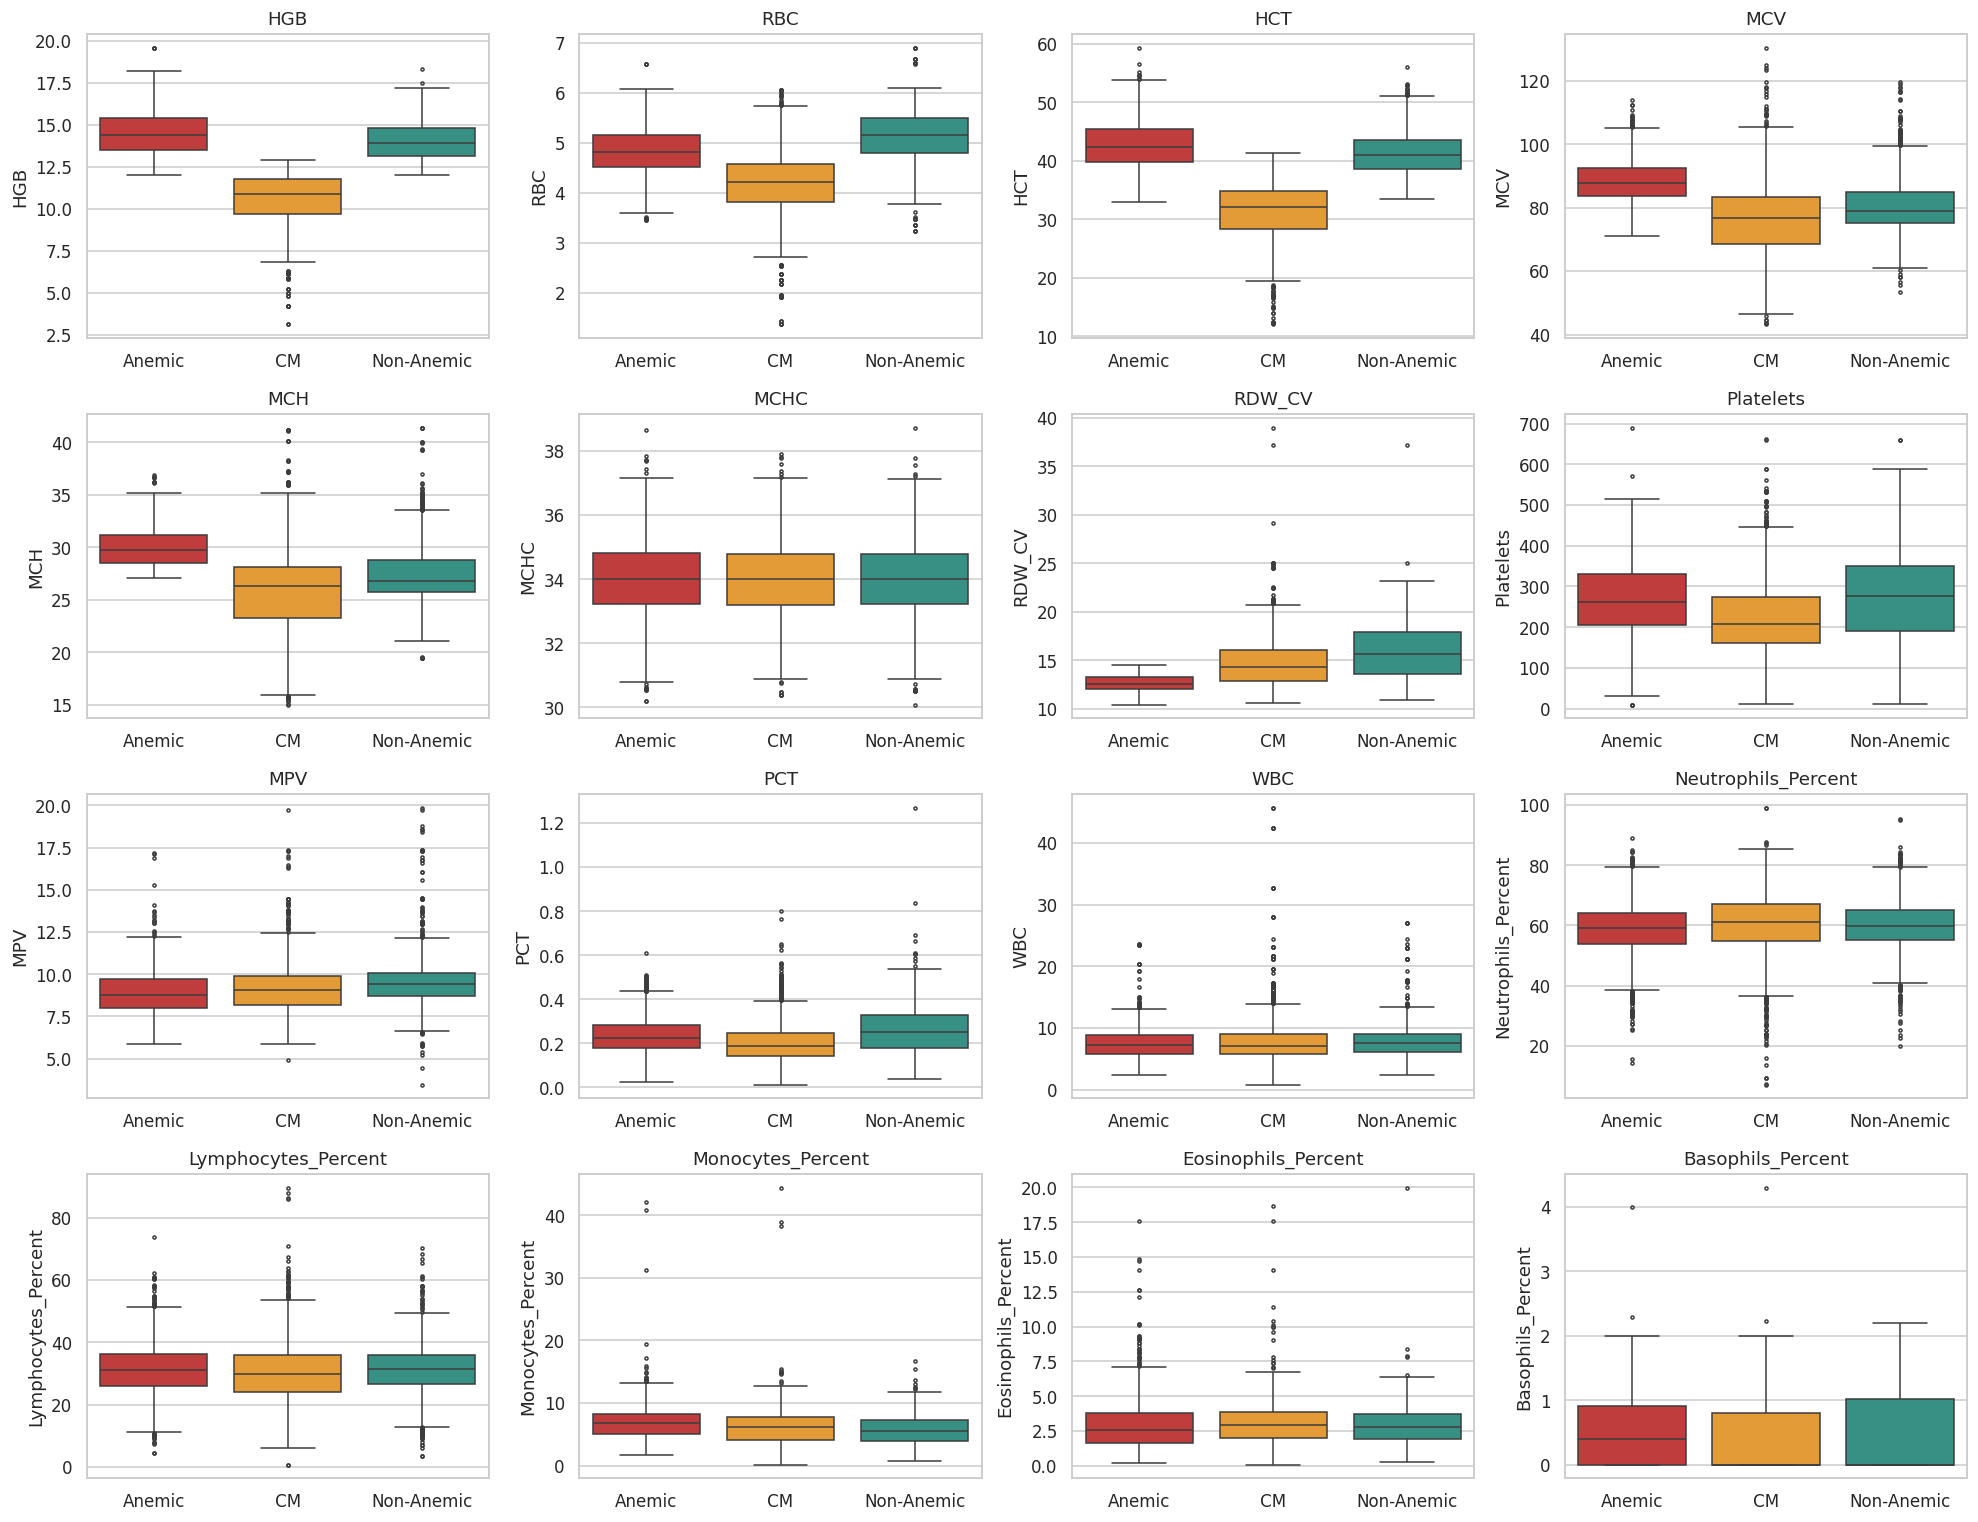

In [11]:
rows = []
for c in CBC_ALL:
    s = dfn[c].dropna(); q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = PLAUS[c]
    rows.append({'variable': c, 'min': s.min(), 'Q1': q1, 'median': s.median(), 'Q3': q3, 'max': s.max(), 'IQR': iqr,
                 'n_IQR_outliers(1.5x)': int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()),
                 'n_implausible(gross)': int(((dfn[c] < lo) | (dfn[c] > hi) | dfn[c].isna()).sum())})
rng = pd.DataFrame(rows).set_index('variable').round(3); save_table(rng, 'EXP04_observed_ranges')

# class-wise IQR outliers
cw = {}
for c in CBC_ALL:
    q1, q3 = dfn[c].quantile([.25, .75]); iqr = q3 - q1
    o = (dfn[c] < q1 - 1.5*iqr) | (dfn[c] > q3 + 1.5*iqr)
    cw[c] = o.groupby(dfn.Class).sum()
save_table(pd.DataFrame(cw).T, 'EXP04_iqr_outliers_by_class')

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, c in zip(axes.ravel(), CBC_ALL):
    sns.boxplot(data=df, x='Class', y=c, order=CLASSES, palette=PALETTE, ax=ax, fliersize=2)
    ax.set_xlabel(''); ax.set_xticklabels([CLS_SHORT[x] for x in CLASSES]); ax.set_title(c)
save_fig('EXP04_boxplots_by_class')

## B. Internal CBC consistency (EXP-05 … EXP-10)
All comparisons use the cleaned copy `df`.

,n,MAE,RMSE,max_abs_err,pearson_r,spearman_rho,median_%err,%within_5%
check,,,,,,,,
EXP-05 HCT = RBC*MCV/10,5035,0.0096,0.0113,0.0296,1.0000,1.0000,0.0241,100.0
EXP-06 MCH = HGB/RBC*10,5037,0.0198,0.0230,0.0400,1.0000,1.0000,0.0710,100.0
EXP-07 MCHC = HGB/HCT*100,5035,0.0203,0.0235,0.0482,0.9998,0.9998,0.0585,100.0
"EXP-08 PCT = Plt*MPV/1e4 (x10^3/uL, fL -> %)",5017,0.0005,0.0006,0.0025,1.0000,1.0000,0.2181,100.0


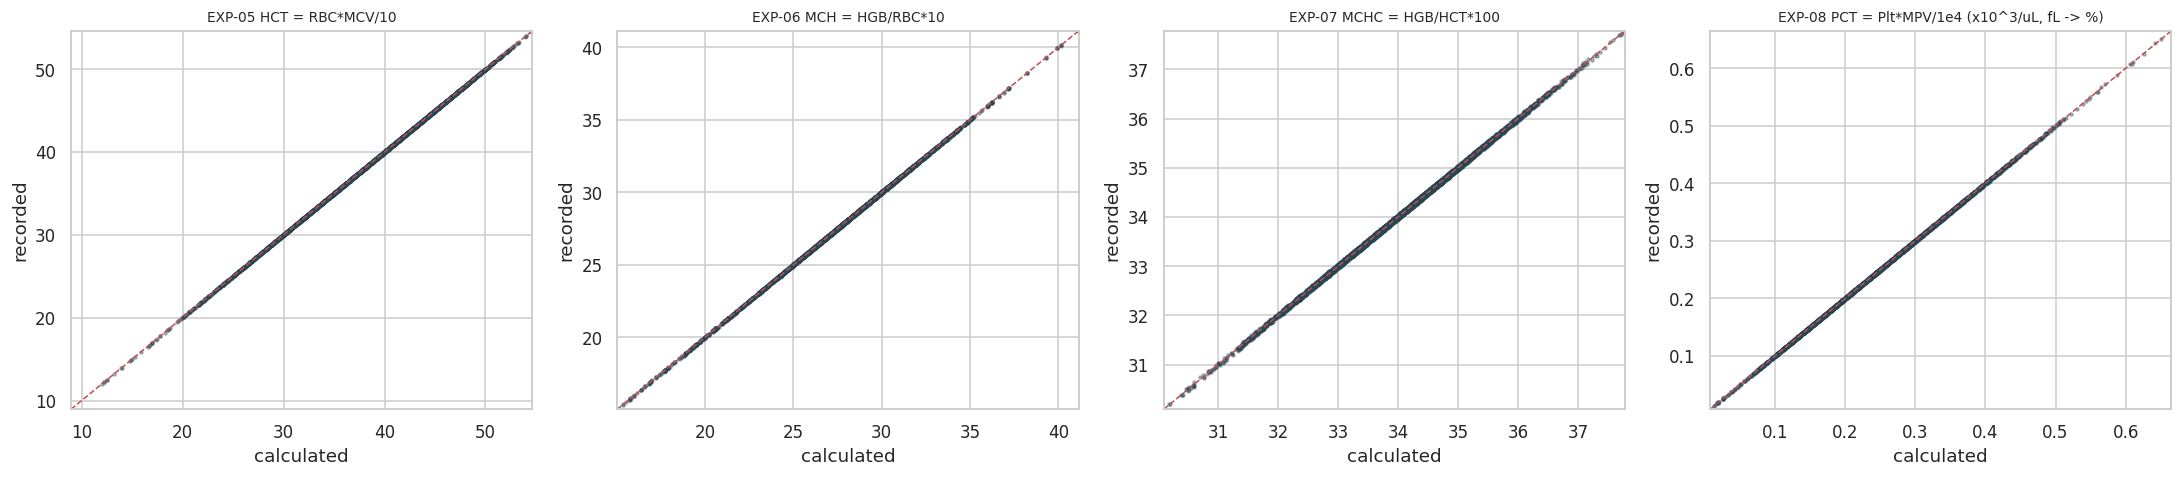

In [12]:
def consistency(name, rec, calc, tol=0.05):
    m = rec.notna() & calc.notna() & np.isfinite(calc); r, c = rec[m], calc[m]; e = r - c
    return {'check': name, 'n': int(m.sum()), 'MAE': e.abs().mean(), 'RMSE': np.sqrt((e**2).mean()), 'max_abs_err': e.abs().max(),
            'pearson_r': stats.pearsonr(r, c)[0], 'spearman_rho': stats.spearmanr(r, c)[0],
            'median_%err': (100*(e.abs()/r.abs())).median(), f'%within_{int(tol*100)}%': 100*((e.abs()/r.abs()) <= tol).mean()}
calc = {
  'EXP-05 HCT = RBC*MCV/10':          (df.HCT,  df.RBC * df.MCV / 10),
  'EXP-06 MCH = HGB/RBC*10':          (df.MCH,  df.HGB / df.RBC * 10),
  'EXP-07 MCHC = HGB/HCT*100':        (df.MCHC, df.HGB / df.HCT * 100),
  'EXP-08 PCT = Plt*MPV/1e4 (x10^3/uL, fL -> %)': (df.PCT, df.Platelets * df.MPV / 1e4),
}
cons = pd.DataFrame([consistency(k, *v) for k, v in calc.items()]).set_index('check').round(4)
save_table(cons, 'EXP05_08_consistency')
for k, r in cons.iterrows():
    w = [c for c in cons.columns if c.startswith('%within')][0]
    if r[w] < 90: note(f'{k}: only {r[w]:.1f}% of records agree within tolerance (verify analyser units/formula before imposing)')

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (k, (rec, cal)) in zip(axes, calc.items()):
    ax.scatter(cal, rec, s=4, alpha=.35, c='#264653'); lim = [np.nanmin([rec.min(), cal.min()]), np.nanmax([rec.quantile(.999), cal.quantile(.999)])]
    ax.plot(lim, lim, 'r--', lw=1); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_title(k, fontsize=9); ax.set_xlabel('calculated'); ax.set_ylabel('recorded')
save_fig('EXP05_08_consistency_scatter')

# worst-agreement records for each identity
worst = []
for k, (rec, cal) in calc.items():
    e = ((rec - cal).abs() / rec.abs()).sort_values(ascending=False).head(5)
    for i, v in e.items(): worst.append({'check': k, 'PID': df.at[i, 'PID'], 'recorded': rec[i], 'calculated': round(cal[i], 3), 'rel_err': round(v, 3)})
save_table(pd.DataFrame(worst), 'EXP05_08_worst_records', index=False, show=False)

### EXP-09 — Differential WBC sums to ~100 %

,mean,SD,min,max,%|sum-100|<=1,%|sum-100|<=2,%|sum-100|<=5
0,99.999,0.04,99.892,100.11,100.0,100.0,100.0


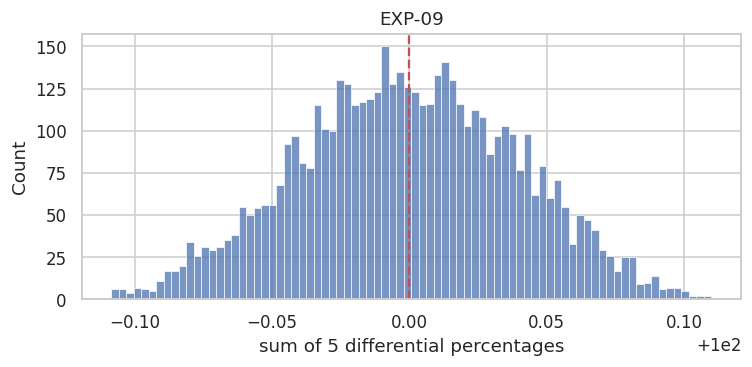

In [13]:
dsum = df[DIFF].sum(axis=1)
diff_tab = pd.DataFrame({'mean': [dsum.mean()], 'SD': [dsum.std()], 'min': [dsum.min()], 'max': [dsum.max()],
                         '%|sum-100|<=1': [100*((dsum-100).abs() <= 1).mean()], '%|sum-100|<=2': [100*((dsum-100).abs() <= 2).mean()],
                         '%|sum-100|<=5': [100*((dsum-100).abs() <= 5).mean()]}).round(3)
save_table(diff_tab, 'EXP09_differential_sum', index=False)
plt.figure(figsize=(7, 3.5)); sns.histplot(dsum, bins=80); plt.axvline(100, c='r', ls='--'); plt.xlabel('sum of 5 differential percentages'); plt.title('EXP-09')
save_fig('EXP09_differential_sum_hist')
if ((dsum-100).abs() > 2).mean() > .05: note(f'EXP-09: {100*((dsum-100).abs()>2).mean():.1f}% of records have differential sum outside 100+-2')

### EXP-10 — Correlation structure

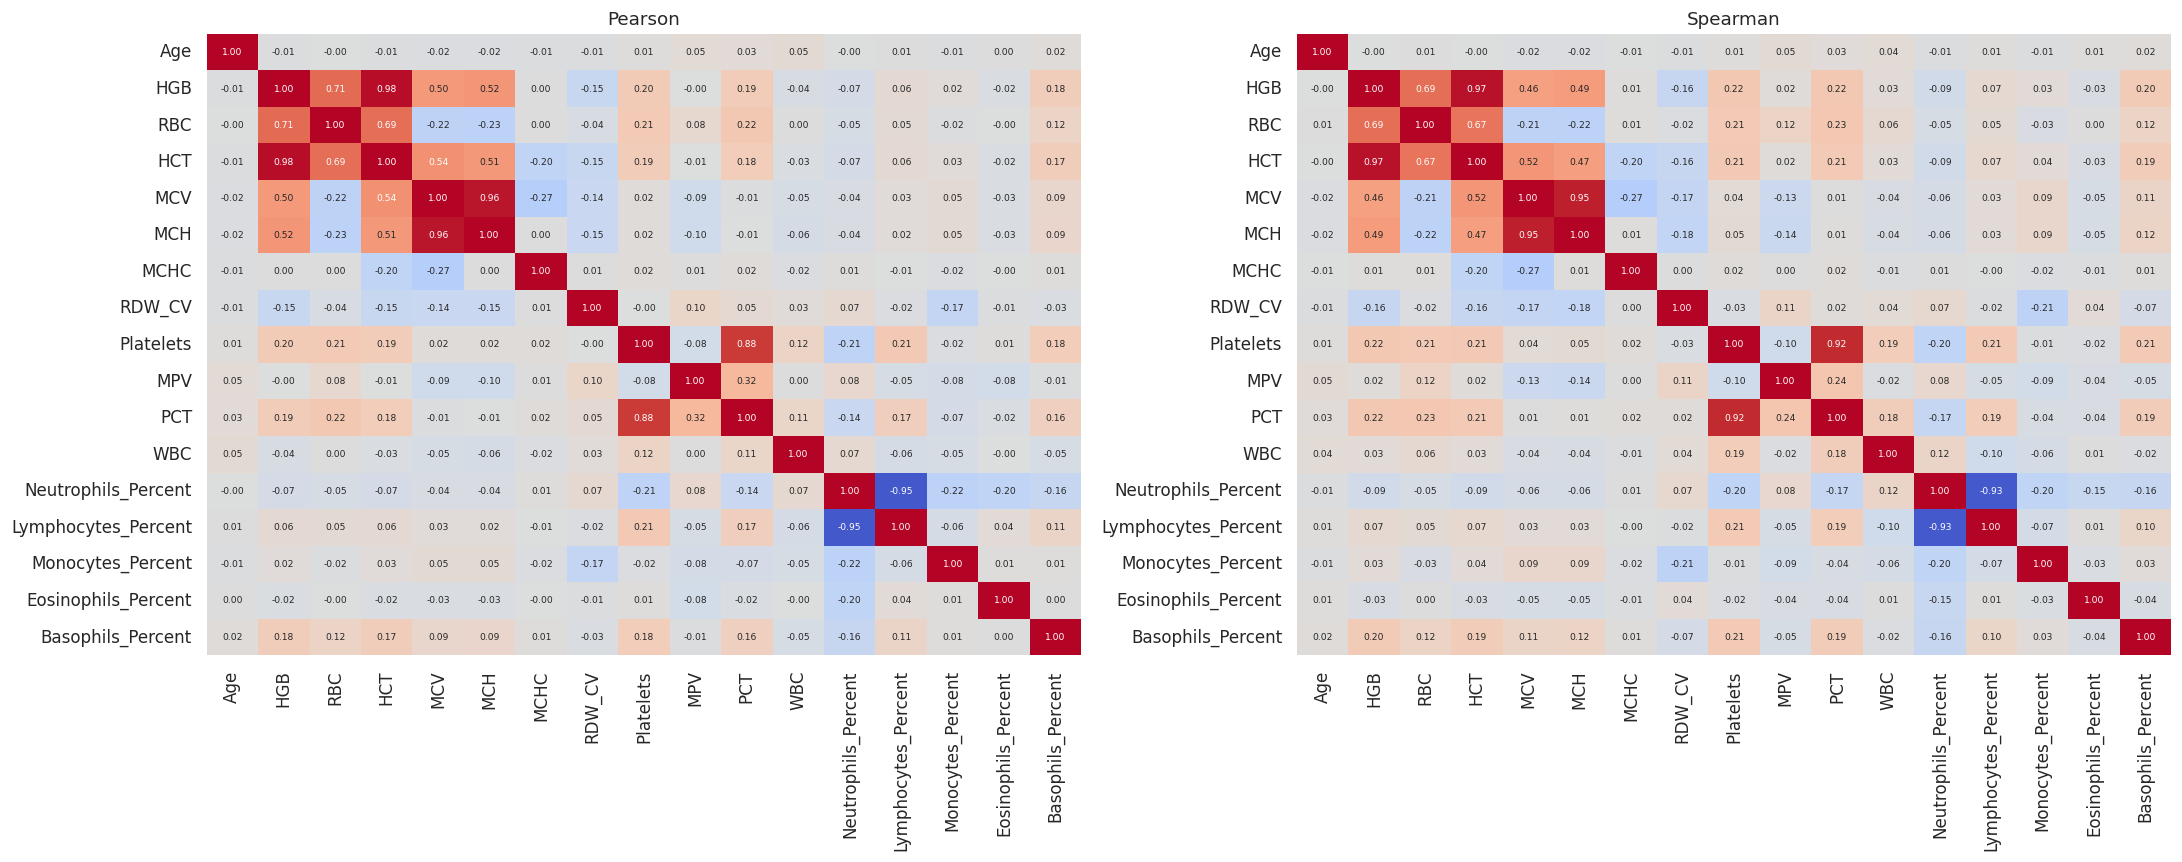

,pearson,spearman
pair,,
HGB <-> HCT,0.978,0.972
HGB <-> MCH,0.518,0.487
RBC <-> HCT,0.688,0.670
MCV <-> MCH,0.962,0.950
MCH <-> MCHC,0.005,0.008
Platelets <-> PCT,0.875,0.922
WBC <-> Neutrophils_Percent,0.070,0.115
WBC <-> Lymphocytes_Percent,-0.056,-0.101
HGB <-> MCHC,0.003,0.011


In [14]:
pear = df[['Age'] + CBC_ALL].corr('pearson'); spear = df[['Age'] + CBC_ALL].corr('spearman')
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, M, t in zip(axes, [pear, spear], ['Pearson', 'Spearman']):
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, annot_kws={'size': 6}, cbar=False); ax.set_title(t)
save_fig('EXP10_correlation_matrices')
pairs = [('HGB','HCT'),('HGB','MCH'),('RBC','HCT'),('MCV','MCH'),('MCH','MCHC'),('Platelets','PCT'),
         ('WBC','Neutrophils_Percent'),('WBC','Lymphocytes_Percent'),('HGB','MCHC'),('RBC','MCV')]
kp = pd.DataFrame([{'pair': f'{a} <-> {b}', 'pearson': pear.loc[a, b], 'spearman': spear.loc[a, b]} for a, b in pairs]).set_index('pair').round(3)
save_table(kp, 'EXP10_key_pair_correlations')

## C. Label validation (EXP-11)

The decision rule is tested exactly as proposed: `HGB < T_H → Anemic`; `HGB ≥ T_H & MCV < 80 → CM`; `HGB ≥ T_H & MCV ≥ 80 → Non-Anemic`.
`T_H` is sex-specific; the code first **infers it empirically** from the released labels (largest HGB among Anemic vs smallest HGB among non-Anemic, per sex).

,max HGB (Anemic),min HGB (non-Anemic),clean separation
Gender,,,
Female,19.6,3.1,False
Male,19.6,4.2,False


Sex-specific thresholds T_H = Male 13.0 / Female 12.0 consistent with released labels: False
  >> EXP-11: WHO thresholds (13.0/12.0 g/dL) are NOT consistent with released Anemic labels - define T_H explicitly
Rule reproduction: accuracy=0.1807  kappa=-0.2247  disagreements=4127


Rule (HGB<T_H; MCV<80),Anemic,Compensated Microcytosis,Non-Anemic
Released,,,
Anemic,148,111,1405
Compensated Microcytosis,1401,151,180
Non-Anemic,321,709,611


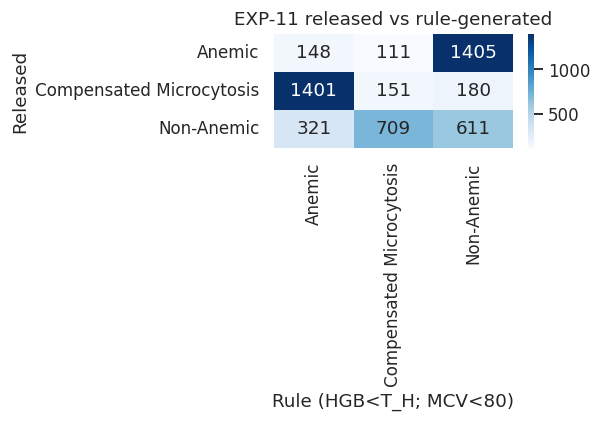

,precision,recall,f1-score,support
Anemic,0.0791,0.0889,0.0838,1664.0000
Compensated Microcytosis,0.1555,0.0872,0.1117,1732.0000
Non-Anemic,0.2782,0.3723,0.3185,1641.0000
accuracy,0.1807,0.1807,0.1807,0.1807
macro avg,0.1710,0.1828,0.1713,5037.0000
weighted avg,0.1703,0.1807,0.1698,5037.0000


All 4127 disagreements saved -> EXP11_all_disagreements.csv


,PID,Gender,Age,HGB,MCV,MCH,RDW_CV,Class,Rule_label
0,PID_0001,Female,24.0,13.2,77.8838,26.9332,11.9816,Non-Anemic,Compensated Microcytosis
1,PID_0002,Female,24.0,14.2,81.4890,27.6128,13.8309,Anemic,Non-Anemic
2,PID_0003,Female,28.0,9.6,48.7960,16.9890,20.0382,Compensated Microcytosis,Anemic
3,PID_0004,Female,41.0,13.8,80.5425,28.8824,12.9998,Anemic,Non-Anemic
4,PID_0005,Male,40.0,13.4,85.4846,28.8469,13.0308,Anemic,Non-Anemic
5,PID_0006,Female,76.0,11.3,79.0452,26.6395,14.8645,Compensated Microcytosis,Anemic
6,PID_0007,Male,20.0,11.5,77.3738,27.8176,13.1928,Compensated Microcytosis,Anemic
7,PID_0008,Female,24.0,12.7,84.7337,29.6378,14.5303,Compensated Microcytosis,Non-Anemic
8,PID_0009,Male,28.0,12.4,74.5093,24.9059,16.1934,Non-Anemic,Anemic
10,PID_0011,Female,16.0,12.0,86.2716,28.8593,17.8938,Compensated Microcytosis,Non-Anemic


Anemic-vs-not split reproduced by sex-specific HGB rule: 35.72%
  >> EXP-11: the MCV<80 rule reproduces only 18.07% of released labels (4127 disagreements; kappa=-0.225); HGB split is 35.72% exact


In [15]:
from sklearn.metrics import (accuracy_score, cohen_kappa_score, confusion_matrix, classification_report, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, roc_auc_score, average_precision_score,
                             precision_score, recall_score)
inf = []
for g, d in df.groupby('Gender'):
    a_max = d.loc[d.Class == 'Anemic', 'HGB'].max(); n_min = d.loc[d.Class != 'Anemic', 'HGB'].min()
    inf.append({'Gender': g, 'max HGB (Anemic)': a_max, 'min HGB (non-Anemic)': n_min, 'clean separation': a_max < n_min})
inf = pd.DataFrame(inf).set_index('Gender'); save_table(inf, 'EXP11_inferred_HGB_threshold')
TH = {'Male': 13.0, 'Female': 12.0}   # WHO adult thresholds; verified above
ok = all(inf.loc[g, 'max HGB (Anemic)'] < TH[g] <= inf.loc[g, 'min HGB (non-Anemic)'] for g in TH)
print('Sex-specific thresholds T_H = Male 13.0 / Female 12.0 consistent with released labels:', ok)
if not ok: note('EXP-11: WHO thresholds (13.0/12.0 g/dL) are NOT consistent with released Anemic labels - define T_H explicitly')

def rule_labels(d, mcv_thr=80.0, dT=0.0, th=TH):
    thr = d.Gender.map(th) + dT
    return pd.Series(np.where(d.HGB < thr, 'Anemic', np.where(d.MCV < mcv_thr, 'Compensated Microcytosis', 'Non-Anemic')), index=d.index)

def agree(y_true, y_pred):
    return {'accuracy': accuracy_score(y_true, y_pred), 'kappa': cohen_kappa_score(y_true, y_pred), 'n_disagree': int((y_true != y_pred).sum())}

pred = rule_labels(df); res = agree(df.Class, pred)
print(f"Rule reproduction: accuracy={res['accuracy']:.4f}  kappa={res['kappa']:.4f}  disagreements={res['n_disagree']}")
cm = pd.crosstab(df.Class, pred, rownames=['Released'], colnames=['Rule (HGB<T_H; MCV<80)']).reindex(index=CLASSES, columns=CLASSES, fill_value=0)
save_table(cm, 'EXP11_confusion_matrix')
plt.figure(figsize=(5.5, 4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('EXP-11 released vs rule-generated'); save_fig('EXP11_confusion')
save_table(pd.DataFrame(classification_report(df.Class, pred, output_dict=True, zero_division=0)).T.round(4), 'EXP11_class_agreement')
dis = df.loc[df.Class != pred, ['PID','Gender','Age','HGB','MCV','MCH','RDW_CV','Class']].assign(Rule_label=pred[df.Class != pred])
save_table(dis, 'EXP11_all_disagreements', index=False, show=False); print(f'All {len(dis)} disagreements saved -> EXP11_all_disagreements.csv'); display(dis.head(10))
hgb_part = ((df.HGB < df.Gender.map(TH)) == (df.Class == 'Anemic')).mean()
print(f'Anemic-vs-not split reproduced by sex-specific HGB rule: {100*hgb_part:.2f}%')
if res['n_disagree'] > 0:
    note(f"EXP-11: the MCV<80 rule reproduces only {100*res['accuracy']:.2f}% of released labels ({res['n_disagree']} disagreements; kappa={res['kappa']:.3f}); HGB split is {100*hgb_part:.2f}% exact")

### EXP-11b — What actually separates CM from Non-Anemic? (rule discovery)
If `MCV < 80` alone does not reproduce the released CM labels, this cell searches, **among HGB ≥ T_H records**, for the simple rule that does. This is a *label-provenance audit* — use it to make the paper's label definition match the released data.

In [16]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold
na = df[df.Class != 'Anemic'].copy(); is_cm = (na.Class == 'Compensated Microcytosis')
cand = ['MCV','MCH','MCHC','RDW_CV','RBC','HCT','HGB','Platelets','MPV','WBC','Age']
Xn = na[cand].fillna(na[cand].median())
rows = []
for dep in [1, 2, 3, 4]:
    t = DecisionTreeClassifier(max_depth=dep, random_state=SEED)
    rows.append({'max_depth': dep, 'CV accuracy (CM vs Non-Anemic, HGB>=T_H)': cross_val_score(t, Xn, is_cm, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).mean()})
save_table(pd.DataFrame(rows).round(4), 'EXP11b_tree_depth')
print(export_text(DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(Xn, is_cm), feature_names=cand))

# threshold scan for single variables and simple combinations
def scan(v, lo, hi, direction='<', steps=200):
    best = (0, None)
    for t in np.linspace(lo, hi, steps):
        acc = (((na[v] < t) if direction == '<' else (na[v] > t)) == is_cm).mean()
        if acc > best[0]: best = (acc, t)
    return best
rows = []
for v, lo, hi, dr in [('MCV', 65, 95, '<'), ('MCH', 22, 32, '<'), ('MCHC', 30, 36, '<'), ('RDW_CV', 11, 20, '>')]:
    a, t = scan(v, lo, hi, dr); rows.append({'rule': f'{v} {dr} t', 'best_threshold': round(t, 2), 'accuracy_among_HGB>=T_H': a})
for name, r in {'MCV<80': na.MCV < 80, 'MCH<27': na.MCH < 27, 'RDW_CV>14.5': na.RDW_CV > 14.5,
                'MCH<27 OR RDW_CV>14.5': (na.MCH < 27) | (na.RDW_CV > 14.5),
                'MCV<80 OR MCH<27 OR RDW_CV>14.5': (na.MCV < 80) | (na.MCH < 27) | (na.RDW_CV > 14.5)}.items():
    rows.append({'rule': name, 'best_threshold': np.nan, 'accuracy_among_HGB>=T_H': (r == is_cm).mean()})
disc = pd.DataFrame(rows).round(4); save_table(disc, 'EXP11b_rule_discovery', index=False)
best = disc.sort_values('accuracy_among_HGB>=T_H', ascending=False).iloc[0]
if best['rule'] != 'MCV<80' and best['accuracy_among_HGB>=T_H'] > (na.MCV < 80).eq(is_cm).mean() + 0.05:
    note(f"EXP-11b: among HGB>=T_H, released CM labels are far better explained by '{best['rule']}' ({100*best['accuracy_among_HGB>=T_H']:.1f}%) than by MCV<80 ({100*(na.MCV<80).eq(is_cm).mean():.1f}%). The paper's label definition must match the data.")

,max_depth,"CV accuracy (CM vs Non-Anemic, HGB>=T_H)"
0,1,0.9019
1,2,0.9019
2,3,0.9300
3,4,0.9372


|--- HGB <= 12.11
|   |--- HGB <= 11.95
|   |   |--- class: True
|   |--- HGB >  11.95
|   |   |--- class: True
|--- HGB >  12.11
|   |--- HGB <= 12.91
|   |   |--- class: False
|   |--- HGB >  12.91
|   |   |--- class: False



,rule,best_threshold,accuracy_among_HGB>=T_H
0,MCV < t,71.63,0.6060
1,MCH < t,24.41,0.6190
2,MCHC < t,35.82,0.5123
3,RDW_CV > t,11.05,0.5168
4,MCV<80,NaN,0.5304
5,MCH<27,NaN,0.5200
6,RDW_CV>14.5,NaN,0.4160
7,MCH<27 OR RDW_CV>14.5,NaN,0.4109
8,MCV<80 OR MCH<27 OR RDW_CV>14.5,NaN,0.4231


  >> EXP-11b: among HGB>=T_H, released CM labels are far better explained by 'MCH < t' (61.9%) than by MCV<80 (53.0%). The paper's label definition must match the data.


## D. Threshold sensitivity (EXP-12, EXP-13)

,n_Anemic,n_CM,n_Non-Anemic,accuracy,kappa,n_disagree,CM sensitivity,CM specificity
MCV threshold,,,,,,,,
78,1870,691,2476,0.2067,-0.1840,3996,0.0676,0.8263
79,1870,814,2353,0.1961,-0.2005,4049,0.0779,0.7946
80,1870,971,2196,0.1807,-0.2247,4127,0.0872,0.7519
81,1870,1114,2053,0.1689,-0.2431,4186,0.0930,0.7116
82,1870,1227,1940,0.1652,-0.2495,4205,0.1010,0.6817


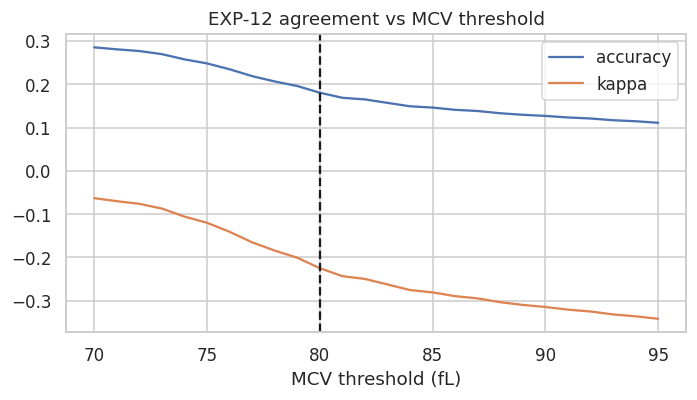

In [17]:
def cm_sens_spec(y, p, pos='Compensated Microcytosis'):
    tp = ((y == pos) & (p == pos)).sum(); fn = ((y == pos) & (p != pos)).sum()
    tn = ((y != pos) & (p != pos)).sum(); fp = ((y != pos) & (p == pos)).sum()
    return tp / (tp + fn), tn / (tn + fp)
rows = []
for t in [78, 79, 80, 81, 82]:
    p = rule_labels(df, mcv_thr=t); s, sp = cm_sens_spec(df.Class, p)
    vc = p.value_counts()
    rows.append({'MCV threshold': t, **{f'n_{CLS_SHORT[c]}': int(vc.get(c, 0)) for c in CLASSES}, **agree(df.Class, p), 'CM sensitivity': s, 'CM specificity': sp})
e12 = pd.DataFrame(rows).set_index('MCV threshold').round(4); save_table(e12, 'EXP12_mcv_threshold_sensitivity')
# wider scan for the figure
sc = []
for t in np.arange(70, 96, 1.0):
    p = rule_labels(df, mcv_thr=t); a = agree(df.Class, p); sc.append({'t': t, 'accuracy': a['accuracy'], 'kappa': a['kappa']})
sc = pd.DataFrame(sc); plt.figure(figsize=(6.5, 3.8)); plt.plot(sc.t, sc.accuracy, label='accuracy'); plt.plot(sc.t, sc.kappa, label='kappa')
plt.axvline(80, c='k', ls='--'); plt.xlabel('MCV threshold (fL)'); plt.legend(); plt.title('EXP-12 agreement vs MCV threshold'); save_fig('EXP12_mcv_scan')

In [18]:
rows = []
for d in [-0.5, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5]:
    p = rule_labels(df, dT=d); vc = p.value_counts()
    rows.append({'delta HGB (g/dL)': d, 'T_male': 13.0 + d, 'T_female': 12.0 + d,
                 **{f'n_{CLS_SHORT[c]}': int(vc.get(c, 0)) for c in CLASSES}, **agree(df.Class, p),
                 'n_Anemic_label_flips': int(((p == 'Anemic') != (df.Class == 'Anemic')).sum())})
e13 = pd.DataFrame(rows).set_index('delta HGB (g/dL)').round(4); save_table(e13, 'EXP13_hgb_threshold_sensitivity')
print('Sensitivity analysis only - thresholds are NOT being tuned.')

,T_male,T_female,n_Anemic,n_CM,n_Non-Anemic,accuracy,kappa,n_disagree,n_Anemic_label_flips
delta HGB (g/dL),,,,,,,,,
-0.5,12.5,11.5,1470,1176,2391,0.1922,-0.2081,4069,3012
-0.3,12.7,11.7,1653,1072,2312,0.1846,-0.2190,4107,3127
-0.2,12.8,11.8,1723,1035,2279,0.1826,-0.2219,4117,3169
-0.1,12.9,11.9,1782,1011,2244,0.1826,-0.2218,4117,3198
0.0,13.0,12.0,1870,971,2196,0.1807,-0.2247,4127,3238
0.1,13.1,12.1,1952,936,2149,0.1795,-0.2263,4133,3284
0.2,13.2,12.2,2037,905,2095,0.1793,-0.2266,4134,3311
0.3,13.3,12.3,2126,865,2046,0.1781,-0.2282,4140,3350
0.5,13.5,12.5,2311,787,1939,0.1767,-0.2301,4147,3437


Sensitivity analysis only - thresholds are NOT being tuned.


## E. Class separability and statistics (EXP-14 … EXP-16)

,Anemic median [Q1-Q3],Anemic mean±SD,CM median [Q1-Q3],CM mean±SD,Non-Anemic median [Q1-Q3],Non-Anemic mean±SD
variable,,,,,,
HGB,14.40 [13.50-15.40],14.52±1.27,10.90 [9.70-11.80],10.63±1.57,13.90 [13.14-14.80],14.02±1.19
MCV,87.66 [83.71-92.36],88.32±6.45,76.80 [68.53-83.40],76.10±12.24,78.96 [75.10-84.89],80.62±8.57
MCH,29.76 [28.51-31.20],30.00±1.89,26.28 [23.24-28.14],25.84±4.06,26.75 [25.70-28.83],27.39±2.77
RBC,4.82 [4.52-5.15],4.85±0.46,4.22 [3.81-4.58],4.17±0.67,5.15 [4.80-5.50],5.15±0.51
HCT,42.40 [39.85-45.52],42.74±4.03,32.14 [28.43-34.87],31.33±4.75,40.94 [38.52-43.58],41.27±3.75
RDW_CV,12.53 [12.02-13.30],12.66±0.88,14.31 [12.91-16.04],14.74±2.55,15.66 [13.58-17.96],15.66±2.60
MCHC,34.02 [33.21-34.83],34.02±1.21,34.01 [33.19-34.78],34.00±1.20,34.01 [33.22-34.78],34.01±1.18
Platelets,262.00 [206.00-331.00],267.63±87.99,208.00 [160.00-275.00],225.35±94.49,276.00 [190.00-350.00],272.89±94.53
WBC,7.20 [5.80-8.80],7.47±2.43,7.10 [5.70-9.00],7.84±3.90,7.62 [6.01-8.98],7.78±2.70


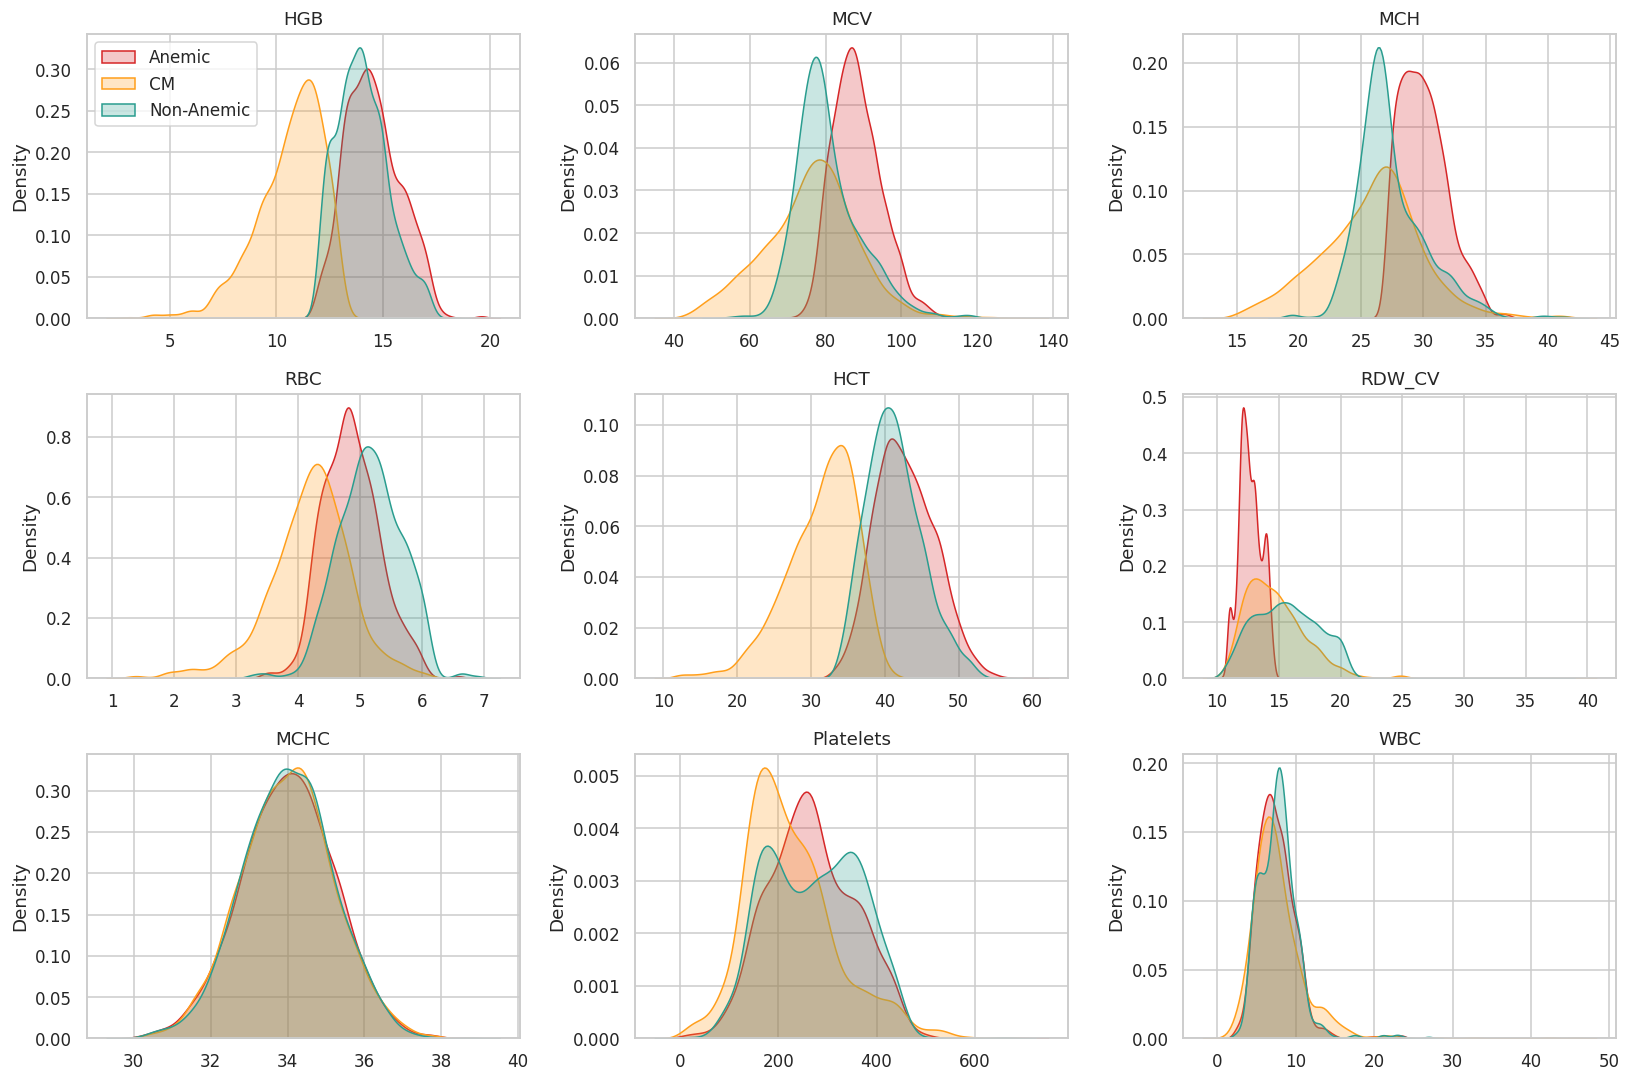

In [19]:
KEYV = ['HGB','MCV','MCH','RBC','HCT','RDW_CV','MCHC','Platelets','WBC']
rows = []
for v in KEYV:
    r = {'variable': v}
    for c in CLASSES:
        s = df.loc[df.Class == c, v].dropna()
        r[f'{CLS_SHORT[c]} median [Q1-Q3]'] = f'{s.median():.2f} [{s.quantile(.25):.2f}-{s.quantile(.75):.2f}]'
        r[f'{CLS_SHORT[c]} mean±SD'] = f'{s.mean():.2f}±{s.std():.2f}'
    rows.append(r)
save_table(pd.DataFrame(rows).set_index('variable'), 'EXP14_class_distributions')
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, v in zip(axes.ravel(), KEYV):
    for c in CLASSES: sns.kdeplot(df.loc[df.Class == c, v].dropna(), ax=ax, color=PALETTE[c], fill=True, alpha=.25, label=CLS_SHORT[c], warn_singular=False)
    ax.set_title(v); ax.set_xlabel('')
axes[0, 0].legend(); save_fig('EXP14_distributions')

### EXP-15 — Significance tests with effect sizes
Shapiro–Wilk decides ANOVA (+Tukey) vs Kruskal–Wallis (+Dunn); pairwise p-values are Holm/Tukey-adjusted; p-values across variables are Holm-adjusted.

In [20]:
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests
def cohens_d(a, b):
    sp_ = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2)); return (a.mean() - b.mean()) / sp_
def cliffs_delta(a, b):
    U = stats.mannwhitneyu(a, b, alternative='two-sided').statistic; return 2 * U / (len(a) * len(b)) - 1
STAT_VARS = ['Age'] + CBC_ALL
rows, prow = [], []
for v in STAT_VARS:
    d = df[[v, 'Class']].dropna(); g = [d.loc[d.Class == c, v] for c in CLASSES]; n = len(d); k = 3
    shp = [stats.shapiro(x.sample(min(len(x), 5000), random_state=SEED)).pvalue for x in g]; normal = all(p > .05 for p in shp)
    H, pk = stats.kruskal(*g); F, pa = stats.f_oneway(*g)
    grand = d[v].mean(); ssb = sum(len(x)*(x.mean()-grand)**2 for x in g); sst = ((d[v]-grand)**2).sum()
    test = 'ANOVA' if normal else 'Kruskal-Wallis'
    rows.append({'variable': v, 'min Shapiro p': min(shp), 'test used': test, 'statistic': F if normal else H,
                 'p': pa if normal else pk, 'epsilon2 (KW)': (H - k + 1) / (n - k), 'eta2 (ANOVA)': ssb / sst})
    post = sp.posthoc_tukey(d, val_col=v, group_col='Class') if normal else sp.posthoc_dunn(d, val_col=v, group_col='Class', p_adjust='holm')
    for a, b in itertools.combinations(CLASSES, 2):
        x, y = d.loc[d.Class == a, v], d.loc[d.Class == b, v]
        prow.append({'variable': v, 'pair': f'{CLS_SHORT[a]} vs {CLS_SHORT[b]}', 'posthoc': 'Tukey' if normal else 'Dunn-Holm',
                     'p_adj': post.loc[a, b], "Cohen's d": cohens_d(x, y), "Cliff's delta": cliffs_delta(x, y)})
e15 = pd.DataFrame(rows).set_index('variable'); e15['p_Holm(across vars)'] = multipletests(e15.p, method='holm')[1]
save_table(e15.round(6), 'EXP15_omnibus_tests')
e15p = pd.DataFrame(prow); save_table(e15p.round(6), 'EXP15_pairwise_posthoc', index=False, show=False); display(e15p.head(12))

,min Shapiro p,test used,statistic,p,epsilon2 (KW),eta2 (ANOVA),p_Holm(across vars)
variable,,,,,,,
Age,0.000000,Kruskal-Wallis,2.608966,0.271313,0.000121,0.000507,0.542626
HGB,0.000000,Kruskal-Wallis,3295.943902,0.000000,0.654339,0.622062,0.000000
RBC,0.000000,Kruskal-Wallis,1870.614275,0.000000,0.371199,0.354122,0.000000
HCT,0.000000,Kruskal-Wallis,3157.705254,0.000000,0.627127,0.595661,0.000000
MCV,0.000000,Kruskal-Wallis,1336.824780,0.000000,0.265162,0.223290,0.000000
MCH,0.000000,Kruskal-Wallis,1521.261421,0.000000,0.301800,0.241770,0.000000
MCHC,0.765432,ANOVA,0.131132,0.877105,-0.000321,0.000052,0.877105
RDW_CV,0.000000,Kruskal-Wallis,1415.141888,0.000000,0.280999,0.248905,0.000000
Platelets,0.000000,Kruskal-Wallis,298.977533,0.000000,0.058994,0.051076,0.000000


,variable,pair,posthoc,p_adj,Cohen's d,Cliff's delta
0,Age,Anemic vs CM,Dunn-Holm,6.063868e-01,-0.023503,-0.011354
1,Age,Anemic vs Non-Anemic,Dunn-Holm,3.320245e-01,-0.055964,-0.032258
2,Age,CM vs Non-Anemic,Dunn-Holm,6.063868e-01,-0.031596,-0.020267
3,HGB,Anemic vs CM,Dunn-Holm,0.000000e+00,2.716190,0.984825
4,HGB,Anemic vs Non-Anemic,Dunn-Holm,3.393638e-14,0.403531,0.221388
5,HGB,CM vs Non-Anemic,Dunn-Holm,0.000000e+00,-2.426503,-0.964344
6,RBC,Anemic vs CM,Dunn-Holm,1.104299e-173,1.176988,0.620471
7,RBC,Anemic vs Non-Anemic,Dunn-Holm,4.712309e-46,-0.622328,-0.352799
8,RBC,CM vs Non-Anemic,Dunn-Holm,0.000000e+00,-1.633565,-0.779527
9,HCT,Anemic vs CM,Dunn-Holm,0.000000e+00,2.584492,0.966487


### EXP-16 — Categorical variables across classes

In [21]:
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct, correction=False)[0]; n = ct.values.sum(); return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
CAT_VARS = ['Gender'] + QUEST_COLS
rows = []
for v in CAT_VARS:
    ct = pd.crosstab(df[v], df.Class)[CLASSES]; chi2, p, dof, exp = stats.chi2_contingency(ct)
    r = {'variable': v, 'chi2': chi2, 'dof': dof, 'p': p, "Cramer's V": cramers_v(ct), 'min expected count': exp.min()}
    for c in CLASSES: r[f'{CLS_SHORT[c]} % positive ({df[v].unique()[0] if False else ("Male" if v=="Gender" else "Yes")})'] = 100 * (df.loc[df.Class == c, v] == ('Male' if v == 'Gender' else 'Yes')).mean()
    # pairwise Fisher (2x2 vs each pair of classes)
    pf = []
    for a, b in itertools.combinations(CLASSES, 2):
        sub = pd.crosstab(df.loc[df.Class.isin([a, b]), v], df.loc[df.Class.isin([a, b]), 'Class']); pf.append(stats.fisher_exact(sub.values)[1])
    for (a, b), padj in zip(itertools.combinations(CLASSES, 2), multipletests(pf, method='holm')[1]): r[f'Fisher-Holm p {CLS_SHORT[a]} v {CLS_SHORT[b]}'] = padj
    rows.append(r)
e16 = pd.DataFrame(rows).set_index('variable'); save_table(e16.round(5), 'EXP16_categorical_tests')

,chi2,dof,p,Cramer's V,min expected count,Anemic % positive (Male),CM % positive (Male),Non-Anemic % positive (Male),Fisher-Holm p Anemic v CM,Fisher-Holm p Anemic v Non-Anemic,Fisher-Holm p CM v Non-Anemic,Anemic % positive (Yes),CM % positive (Yes),Non-Anemic % positive (Yes)
variable,,,,,,,,,,,,,,
Gender,26.73862,2,0.0,0.07286,771.79452,49.21875,42.03233,50.09141,0.00006,0.62628,0.00001,NaN,NaN,NaN
History_Anemia,149.42734,2,0.0,0.17224,376.28648,NaN,NaN,NaN,0.00000,0.00000,0.00000,21.75481,14.95381,32.54113
History_Family,90.13411,2,0.0,0.13377,366.18702,NaN,NaN,NaN,0.00000,0.00004,0.00000,22.77644,15.47344,29.06764
Substance_Use,210.84401,2,0.0,0.20459,347.61703,NaN,NaN,NaN,0.00000,0.00000,0.00000,22.71635,10.56582,30.83486


## F. Demographic characterisation (EXP-17, EXP-18)

,n,mean±SD,median,IQR,range
Class,,,,,
Anemic,1664,47.4±18.0,47.0,32-62,11-89
Compensated Microcytosis,1732,47.8±18.7,47.0,32-64,11-89
Non-Anemic,1641,48.4±18.3,48.0,33-64,11-83
ALL,5037,47.9±18.4,47.0,32-63,11-89


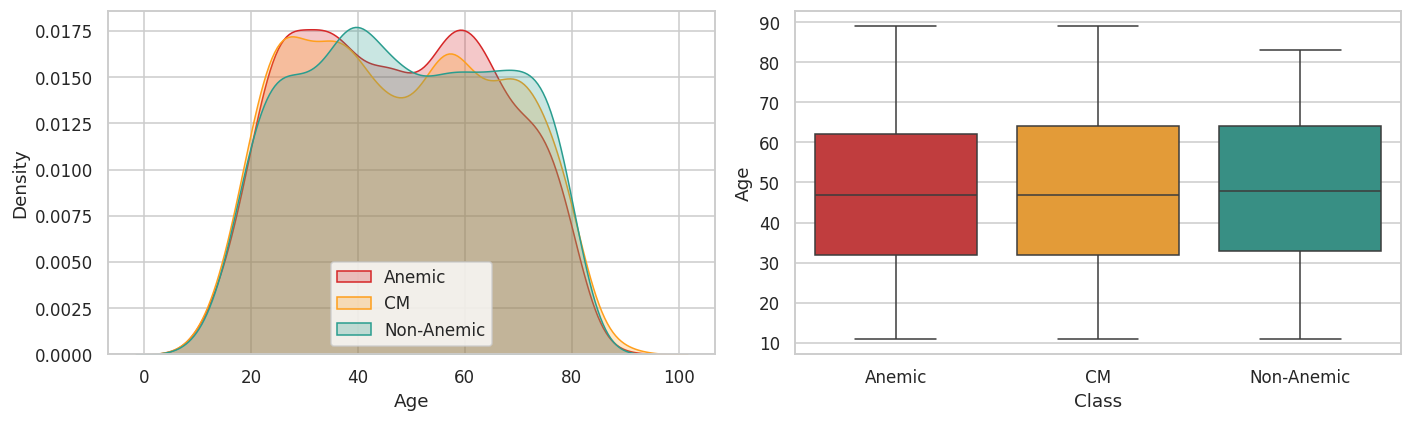

Gender,Male,Female,Male %
Class,,,
Anemic,819,845,49.2
Compensated Microcytosis,728,1004,42.0
Non-Anemic,822,819,50.1


EXP-18 chi2=26.739, dof=2, p=1.562e-06, Cramer V=0.073


In [22]:
rows = []
for c in CLASSES + ['ALL']:
    s = df.Age if c == 'ALL' else df.loc[df.Class == c, 'Age']
    rows.append({'Class': c, 'n': len(s), 'mean±SD': f'{s.mean():.1f}±{s.std():.1f}', 'median': s.median(),
                 'IQR': f'{s.quantile(.25):.0f}-{s.quantile(.75):.0f}', 'range': f'{s.min():.0f}-{s.max():.0f}'})
save_table(pd.DataFrame(rows).set_index('Class'), 'EXP17_age_by_class')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c in CLASSES: sns.kdeplot(df.loc[df.Class == c, 'Age'], ax=ax[0], color=PALETTE[c], fill=True, alpha=.25, label=CLS_SHORT[c])
ax[0].legend(); sns.boxplot(data=df, x='Class', y='Age', order=CLASSES, palette=PALETTE, ax=ax[1]); ax[1].set_xticklabels([CLS_SHORT[c] for c in CLASSES])
save_fig('EXP17_age')
sx = pd.crosstab(df.Class, df.Gender).reindex(CLASSES)[['Male', 'Female']]; sx['Male %'] = (100 * sx.Male / (sx.Male + sx.Female)).round(1)
chi2, p, dof, _ = stats.chi2_contingency(sx[['Male', 'Female']]); save_table(sx, 'EXP18_sex_by_class')
print(f'EXP-18 chi2={chi2:.3f}, dof={dof}, p={p:.4g}, Cramer V={cramers_v(sx[["Male","Female"]]):.3f}')

## G–I. Machine-learning utility, leakage-aware experiments and ablation (EXP-19 … EXP-26)

**Protocol:** stratified 5-fold CV, median imputation inside each pipeline (no leakage from test folds), scaling for LR/SVM/k-NN, primary metric = **Macro-F1**.
`Gender`, `History_*`, `Substance_Use` are binary-encoded. PID and Class are never used as features.
Results are cached, so EXP-20…26 reuse fits where feature-sets/models coincide.

In [23]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

dfm = df.copy()
dfm['Gender'] = (dfm.Gender == 'Male').astype(int)                    # 1 = Male
for c in QUEST_COLS: dfm[c] = (dfm[c] == 'Yes').astype(int)
y_all = dfm.Class.map({c: i for i, c in enumerate(CLASSES)}).values

DEMO, QUEST = ['Age', 'Gender'], QUEST_COLS
CBC_X = [c for c in CBC_ALL if c not in ('HGB', 'MCV')]
ALLF = CBC_ALL + DEMO + QUEST
FS = {   # feature sets
 'ALL features (EXP-20)':                         ALLF,
 'ALL minus HGB,MCV (EXP-21/25 combined)':        CBC_X + DEMO + QUEST,
 'HGB+MCV only (EXP-22)':                         ['HGB', 'MCV'],
 'HGB+MCH+RDW_CV (rule-audit, EXP-22b)':          ['HGB', 'MCH', 'RDW_CV', 'Gender'],
 'CBC minus HGB,MCV (EXP-23)':                    CBC_X,
 'Questionnaire+demographic (EXP-24)':            QUEST + DEMO,
 # ablation A-G
 'A: HGB+MCV':                                    ['HGB', 'MCV'],
 'B: HGB+MCV+demographic':                        ['HGB', 'MCV'] + DEMO,
 'C: CBC excl. HGB/MCV':                          CBC_X,
 'D: Questionnaire only':                         QUEST,
 'E: All CBC':                                    CBC_ALL,
 'F: Questionnaire+demographic':                  QUEST + DEMO,
 'G: All features':                               ALLF,
}

def make_models(seed):
    imp = lambda: SimpleImputer(strategy='median')
    from sklearn.preprocessing import StandardScaler
    M = {
     'Logistic Regression': Pipeline([('i', imp()), ('s', StandardScaler()), ('m', LogisticRegression(max_iter=3000, random_state=seed))]),
     'Decision Tree':       Pipeline([('i', imp()), ('m', DecisionTreeClassifier(min_samples_leaf=5, random_state=seed))]),
     'Random Forest':       Pipeline([('i', imp()), ('m', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed))]),
     'Extra Trees':         Pipeline([('i', imp()), ('m', ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=seed))]),
     'SVM (RBF)':           Pipeline([('i', imp()), ('s', StandardScaler()), ('m', SVC(probability=True, random_state=seed))]),
     'k-NN':                Pipeline([('i', imp()), ('s', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=15))]),
    }
    try:
        from xgboost import XGBClassifier
        M['XGBoost'] = Pipeline([('i', imp()), ('m', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=.08, subsample=.9, colsample_bytree=.9,
                                                                  eval_metric='mlogloss', n_jobs=-1, random_state=seed, verbosity=0))])
    except Exception as e: print('XGBoost unavailable', e)
    try:
        from lightgbm import LGBMClassifier
        M['LightGBM'] = Pipeline([('i', imp()), ('m', LGBMClassifier(n_estimators=300, learning_rate=.05, num_leaves=31, n_jobs=-1, random_state=seed, verbose=-1))])
    except Exception as e: print('LightGBM unavailable', e)
    try:
        from catboost import CatBoostClassifier
        M['CatBoost'] = Pipeline([('i', imp()), ('m', CatBoostClassifier(iterations=300, depth=6, learning_rate=.08, verbose=0, random_seed=seed, thread_count=-1, allow_writing_files=False))])
    except Exception as e: print('CatBoost unavailable', e)
    return M

MODEL_NAMES = list(make_models(0).keys())
PRIMARY = 'XGBoost' if 'XGBoost' in MODEL_NAMES else 'Random Forest'
print('Models:', MODEL_NAMES, '| PRIMARY =', PRIMARY)

def metrics_from(y, P):
    pred = P.argmax(1); yb = label_binarize(y, classes=[0, 1, 2])
    return {'Accuracy': accuracy_score(y, pred), 'Macro-F1': f1_score(y, pred, average='macro'), 'Weighted-F1': f1_score(y, pred, average='weighted'),
            'Balanced Acc': balanced_accuracy_score(y, pred), 'Macro Precision': precision_score(y, pred, average='macro', zero_division=0),
            'Macro Recall': recall_score(y, pred, average='macro', zero_division=0), 'MCC': matthews_corrcoef(y, pred),
            'ROC-AUC (macro OVR)': roc_auc_score(y, P, multi_class='ovr', average='macro'),
            'PR-AUC (macro OVR)': np.mean([average_precision_score(yb[:, k], P[:, k]) for k in range(3)])}

CACHE = {}
def run(fs_name, model_name, seed=SEED):
    key = (tuple(FS[fs_name]), model_name, seed)
    if key in CACHE: return CACHE[key]
    X = dfm[FS[fs_name]]; model = make_models(seed)[model_name]
    skf = StratifiedKFold(N_SPLITS, shuffle=True, random_state=seed); oof = np.zeros((len(X), 3)); rows = []
    for tr, te in skf.split(X, y_all):
        m = clone(model).fit(X.iloc[tr], y_all[tr]); P = m.predict_proba(X.iloc[te]); oof[te] = P; rows.append(metrics_from(y_all[te], P))
    CACHE[key] = (pd.DataFrame(rows), oof); return CACHE[key]

def summarize(results, fmt=True):
    # results: dict name -> fold DataFrame
    num = pd.DataFrame({k: v.mean() for k, v in results.items()}).T
    sd = pd.DataFrame({k: v.std() for k, v in results.items()}).T
    return (num.round(4).astype(str) + ' ± ' + sd.round(4).astype(str)) if fmt else num

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'SVM (RBF)', 'k-NN', 'XGBoost', 'LightGBM', 'CatBoost'] | PRIMARY = XGBoost


### EXP-19 / EXP-20 — Nine-model baseline benchmark on all features

Logistic Regression    Macro-F1 = 0.9238  (2s)
Decision Tree          Macro-F1 = 0.9982  (3s)
Random Forest          Macro-F1 = 0.9941  (25s)
Extra Trees            Macro-F1 = 0.9698  (40s)
SVM (RBF)              Macro-F1 = 0.9321  (51s)
k-NN                   Macro-F1 = 0.8499  (52s)
XGBoost                Macro-F1 = 0.9988  (57s)
LightGBM               Macro-F1 = 0.9982  (71s)
CatBoost               Macro-F1 = 0.9982  (98s)


,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,Macro Precision,Macro Recall,MCC,ROC-AUC (macro OVR),PR-AUC (macro OVR)
Logistic Regression,0.9248 ± 0.0109,0.9238 ± 0.0111,0.9247 ± 0.0109,0.9238 ± 0.0111,0.924 ± 0.0112,0.9238 ± 0.0111,0.8872 ± 0.0165,0.9881 ± 0.0026,0.9767 ± 0.0048
Decision Tree,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9973 ± 0.0012,0.9994 ± 0.0006,0.9987 ± 0.0014
Random Forest,0.994 ± 0.0035,0.9941 ± 0.0035,0.994 ± 0.0035,0.9941 ± 0.0035,0.994 ± 0.0035,0.9941 ± 0.0035,0.9911 ± 0.0053,0.9998 ± 0.0002,0.9997 ± 0.0005
Extra Trees,0.97 ± 0.0047,0.9698 ± 0.0047,0.97 ± 0.0047,0.9698 ± 0.0047,0.9699 ± 0.0047,0.9698 ± 0.0047,0.9551 ± 0.007,0.998 ± 0.0005,0.9959 ± 0.0009
SVM (RBF),0.9327 ± 0.0074,0.9321 ± 0.0075,0.9327 ± 0.0074,0.9321 ± 0.0074,0.9323 ± 0.0075,0.9321 ± 0.0074,0.8991 ± 0.011,0.9927 ± 0.0018,0.9862 ± 0.0034
k-NN,0.8509 ± 0.01,0.8499 ± 0.0099,0.8507 ± 0.01,0.8501 ± 0.0099,0.8531 ± 0.0106,0.8501 ± 0.0099,0.7779 ± 0.0153,0.9616 ± 0.0042,0.9208 ± 0.0084
XGBoost,0.9988 ± 0.0011,0.9988 ± 0.0011,0.9988 ± 0.0011,0.9988 ± 0.0011,0.9988 ± 0.0011,0.9988 ± 0.0011,0.9982 ± 0.0016,0.9999 ± 0.0001,0.9998 ± 0.0002
LightGBM,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9982 ± 0.0008,0.9973 ± 0.0012,1.0 ± 0.0001,0.9999 ± 0.0001
CatBoost,0.9982 ± 0.0011,0.9982 ± 0.0011,0.9982 ± 0.0011,0.9982 ± 0.0011,0.9982 ± 0.0011,0.9982 ± 0.0011,0.9973 ± 0.0016,1.0 ± 0.0,0.9999 ± 0.0001


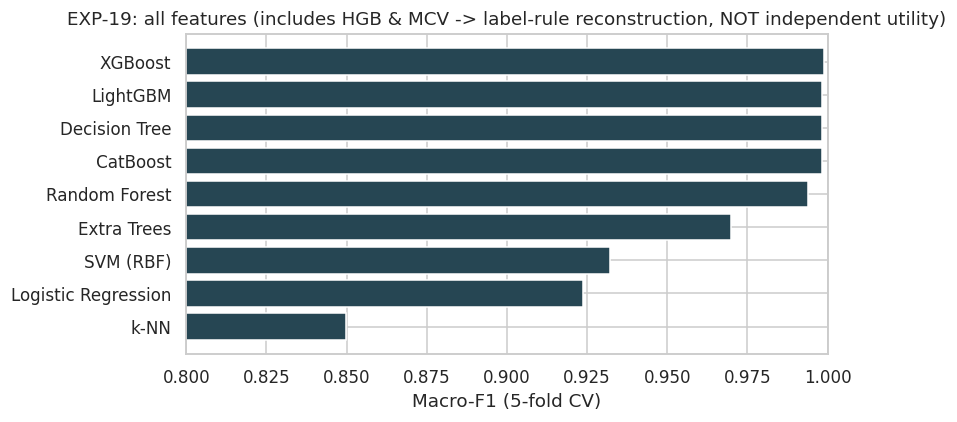

In [24]:
t0 = time.time(); res19 = {}
for mn in MODEL_NAMES:
    res19[mn] = run('ALL features (EXP-20)', mn)[0]; print(f'{mn:22s} Macro-F1 = {res19[mn]["Macro-F1"].mean():.4f}  ({time.time()-t0:.0f}s)')
e19 = summarize(res19); save_table(e19, 'EXP19_20_baseline_benchmark_all_features')
num19 = summarize(res19, fmt=False).sort_values('Macro-F1', ascending=False)
plt.figure(figsize=(8, 4)); plt.barh(num19.index[::-1], num19['Macro-F1'][::-1], color='#264653'); plt.xlim(max(0, num19['Macro-F1'].min() - .05), 1.0)
plt.xlabel('Macro-F1 (5-fold CV)'); plt.title('EXP-19: all features (includes HGB & MCV -> label-rule reconstruction, NOT independent utility)'); save_fig('EXP19_benchmark')

### EXP-21 … EXP-25 — Leakage-aware experiments
EXP-22 is a *label-structure validation*, not a competitive benchmark. EXP-25 compares CBC-only (EXP-23), questionnaire-only (EXP-24) and their combination (= EXP-21 feature set).

n_features  \
feature set                            model                             
ALL features (EXP-20)                  Logistic Regression          21   
                                       Random Forest                21   
                                       XGBoost                      21   
ALL minus HGB,MCV (EXP-21/25 combined) Logistic Regression          19   
                                       Random Forest                19   
                                       XGBoost                      19   
HGB+MCV only (EXP-22)                  Logistic Regression           2   
                                       Random Forest                 2   
                                       XGBoost                       2   
HGB+MCH+RDW_CV (rule-audit, EXP-22b)   Logistic Regression           4   
                                       Random Forest                 4   
                                       XGBoost                       4   
CBC minus HGB,MCV (EXP-23)             Logistic Regression          14   
                                       Random Forest                14   
                                       XGBoost                      14   
Questionnaire+demographic (EXP-24)     Logistic Regression           5   
                                       Random Forest                 5   
                                       XGBoost                       5   

                                                            Accuracy  \
feature set                            model                           
ALL features (EXP-20)                  Logistic Regression    0.9248   
                                       Random Forest          0.9940   
                                       XGBoost                0.9988   
ALL minus HGB,MCV (EXP-21/25 combined) Logistic Regression    0.9208   
                                       Random Forest          0.9623   
                                       XGBoost                0.9879   
HGB+MCV only (EXP-22)                  Logistic Regression    0.7588   
                                       Random Forest          0.7536   
                                       XGBoost                0.7806   
HGB+MCH+RDW_CV (rule-audit, EXP-22b)   Logistic Regression    0.9107   
                                       Random Forest          0.9984   
                                       XGBoost                0.9988   
CBC minus HGB,MCV (EXP-23)             Logistic Regression    0.8674   
                                       Random Forest          0.9321   
                                       XGBoost                0.9379   
Questionnaire+demographic (EXP-24)     Logistic Regression    0.4167   
                                       Random Forest          0.4072   
                                       XGBoost                0.4217   

                                                            Macro-F1  \
feature set                            model                           
ALL features (EXP-20)                  Logistic Regression    0.9238   
                                       Random Forest          0.9941   
                                       XGBoost                0.9988   
ALL minus HGB,MCV (EXP-21/25 combined) Logistic Regression    0.9198   
                                       Random Forest          0.9624   
                                       XGBoost                0.9879   
HGB+MCV only (EXP-22)                  Logistic Regression    0.7553   
                                       Random Forest          0.7502   
                                       XGBoost                0.7760   
HGB+MCH+RDW_CV (rule-audit, EXP-22b)   Logistic Regression    0.9094   
                                       Random Forest          0.9984   
                                       XGBoost                0.9988   
CBC minus HGB,MCV (EXP-23)             Logistic Regression    0.8667   
                                       Random Forest      

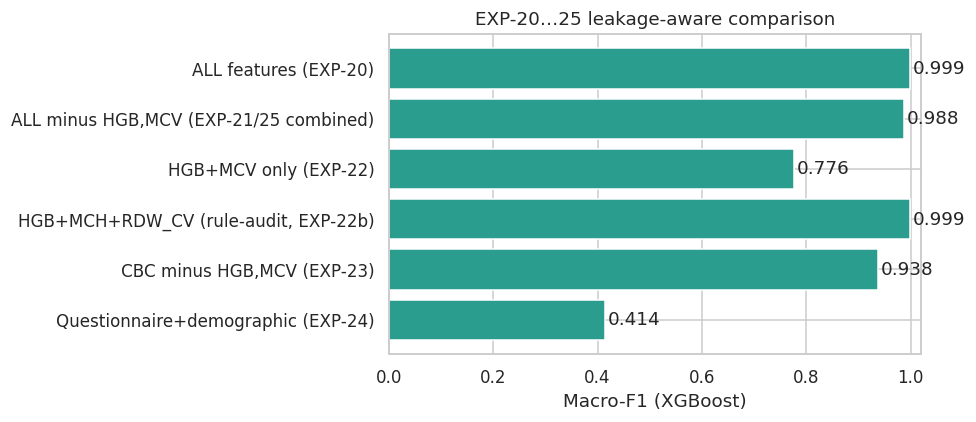

  >> Leakage-aware (XGBoost): Macro-F1 all features 0.999 | HGB+MCV only 0.776 | without HGB/MCV 0.988 | CBC-only 0.938 | questionnaire-only 0.414


In [25]:
lm = MODEL_NAMES if LEAK_MODELS is None else [m for m in LEAK_MODELS if m in MODEL_NAMES]
if PRIMARY not in lm: lm.append(PRIMARY)
leak_sets = ['ALL features (EXP-20)', 'ALL minus HGB,MCV (EXP-21/25 combined)', 'HGB+MCV only (EXP-22)', 'HGB+MCH+RDW_CV (rule-audit, EXP-22b)',
             'CBC minus HGB,MCV (EXP-23)', 'Questionnaire+demographic (EXP-24)']
rows = []
for fsn in leak_sets:
    for mn in lm:
        f, _ = run(fsn, mn); r = f.mean().to_dict(); r.update({'feature set': fsn, 'model': mn, 'n_features': len(FS[fsn]), 'Macro-F1 SD': f['Macro-F1'].std()}); rows.append(r)
e21 = pd.DataFrame(rows).set_index(['feature set', 'model']).round(4); save_table(e21[['n_features','Accuracy','Macro-F1','Macro-F1 SD','Balanced Acc','MCC','ROC-AUC (macro OVR)','PR-AUC (macro OVR)']], 'EXP20_25_leakage_aware')
p = e21.xs(PRIMARY, level='model')['Macro-F1']
plt.figure(figsize=(9, 4)); plt.barh(p.index[::-1], p.values[::-1], color='#2a9d8f'); plt.xlabel(f'Macro-F1 ({PRIMARY})'); plt.xlim(0, 1.02)
for i, v in enumerate(p.values[::-1]): plt.text(v + .005, i, f'{v:.3f}', va='center')
plt.title('EXP-20…25 leakage-aware comparison'); save_fig('EXP20_25_leakage_bar')
a, b = p['ALL features (EXP-20)'], p['ALL minus HGB,MCV (EXP-21/25 combined)']
note(f'Leakage-aware ({PRIMARY}): Macro-F1 all features {a:.3f} | HGB+MCV only {p["HGB+MCV only (EXP-22)"]:.3f} | without HGB/MCV {b:.3f} | CBC-only {p["CBC minus HGB,MCV (EXP-23)"]:.3f} | questionnaire-only {p["Questionnaire+demographic (EXP-24)"]:.3f}')

### EXP-26 — Feature-group ablation (single strong classifier)

,n_features,Macro-F1 mean,Macro-F1 SD,Balanced Acc,MCC,ROC-AUC
set,,,,,,
A: HGB+MCV,2,0.7760,0.0078,0.7781,0.6736,0.9243
B: HGB+MCV+demographic,4,0.8296,0.0059,0.8306,0.7536,0.9389
C: CBC excl. HGB/MCV,14,0.9382,0.0079,0.9384,0.9069,0.9940
D: Questionnaire only,3,0.3453,0.0217,0.4169,0.1495,0.5866
E: All CBC,16,0.9376,0.0076,0.9378,0.9060,0.9951
F: Questionnaire+demographic,5,0.4139,0.0131,0.4194,0.1318,0.5973
G: All features,21,0.9988,0.0011,0.9988,0.9982,0.9999


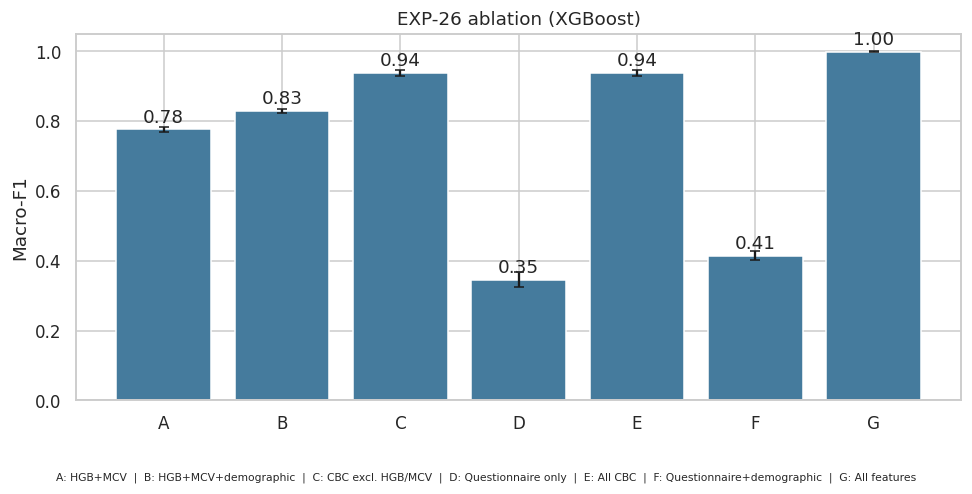

In [26]:
abl_sets = [k for k in FS if re.match(r'^[A-G]:', k)]; rows = []
for fsn in abl_sets:
    f, _ = run(fsn, PRIMARY); rows.append({'set': fsn, 'n_features': len(FS[fsn]), 'Macro-F1 mean': f['Macro-F1'].mean(), 'Macro-F1 SD': f['Macro-F1'].std(),
                                           'Balanced Acc': f['Balanced Acc'].mean(), 'MCC': f['MCC'].mean(), 'ROC-AUC': f['ROC-AUC (macro OVR)'].mean()})
e26 = pd.DataFrame(rows).set_index('set').round(4); save_table(e26, 'EXP26_feature_group_ablation')
plt.figure(figsize=(9, 4.2)); plt.bar(range(len(e26)), e26['Macro-F1 mean'], yerr=e26['Macro-F1 SD'], color='#457b9d', capsize=3)
plt.xticks(range(len(e26)), [s.split(':')[0] for s in e26.index]); plt.ylabel('Macro-F1'); plt.title(f'EXP-26 ablation ({PRIMARY})')
for i, v in enumerate(e26['Macro-F1 mean']): plt.text(i, v + .02, f'{v:.2f}', ha='center')
plt.figtext(.5, -.06, '  |  '.join(e26.index), ha='center', fontsize=7); save_fig('EXP26_ablation')

## J. Explainability (EXP-27)
_Demonstrates dataset utility for explainable AI — not clinical interpretability._

,Anemic,CM,Non-Anemic,Global
HGB,1.4070,3.7137,1.8085,2.3097
MCH,2.2845,0.0167,1.7907,1.3640
RDW_CV,1.9729,0.0000,1.9344,1.3024
Gender,0.2601,1.6572,0.4791,0.7988
HCT,0.1772,0.8869,0.4708,0.5117
MCHC,0.1464,0.1275,0.0760,0.1166
RBC,0.1060,0.0298,0.1017,0.0792
MCV,0.1695,0.0022,0.0551,0.0756
History_Family,0.0019,0.0017,0.1370,0.0469
Eosinophils_Percent,0.0244,0.0008,0.0921,0.0391


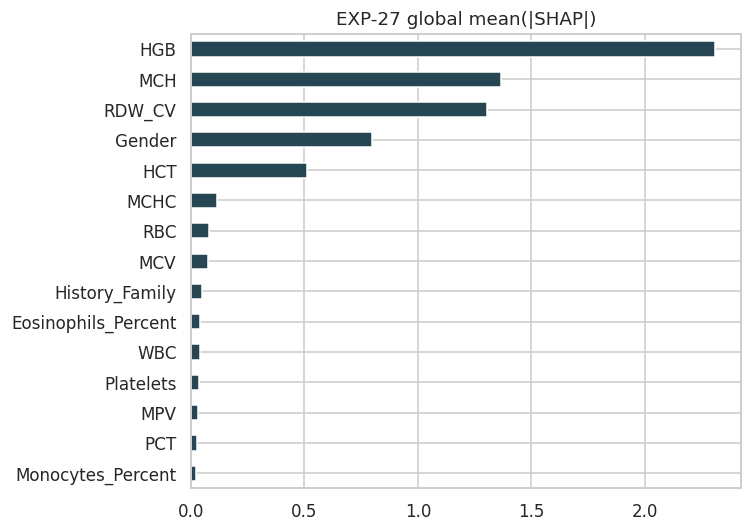

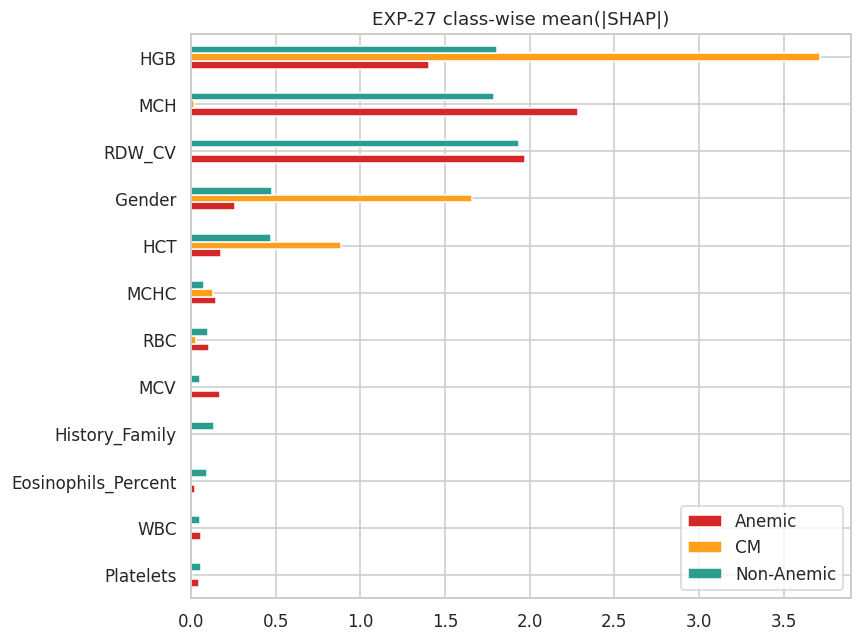

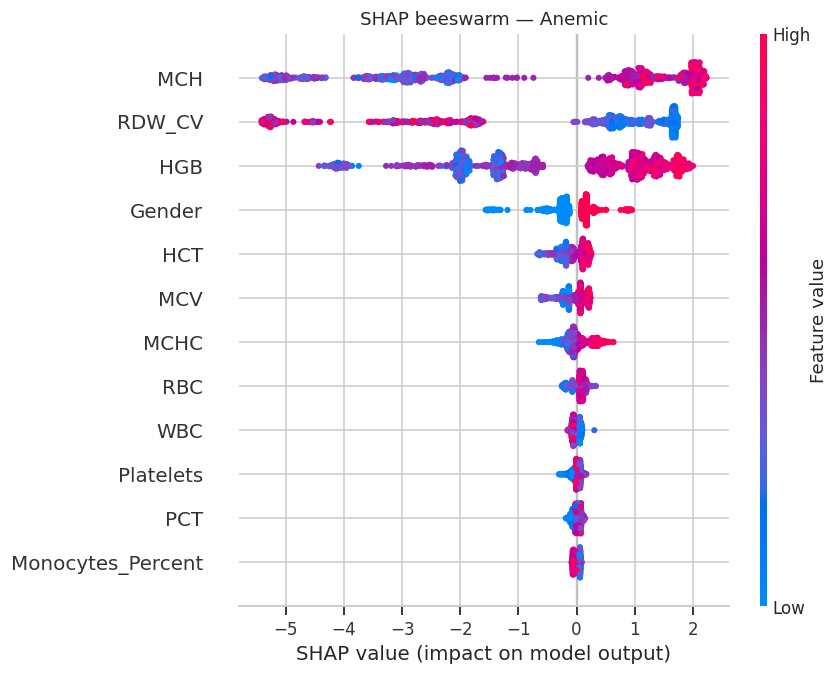

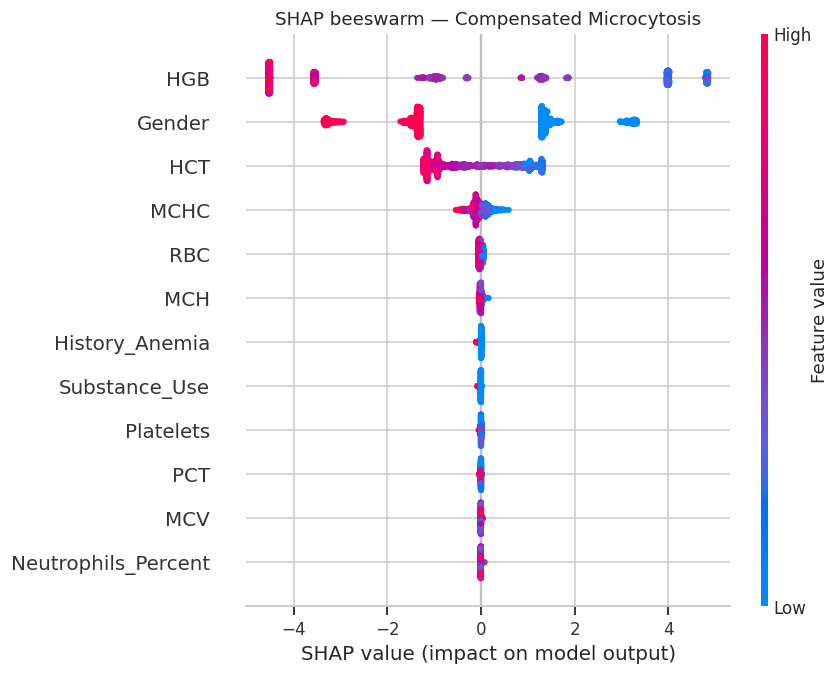

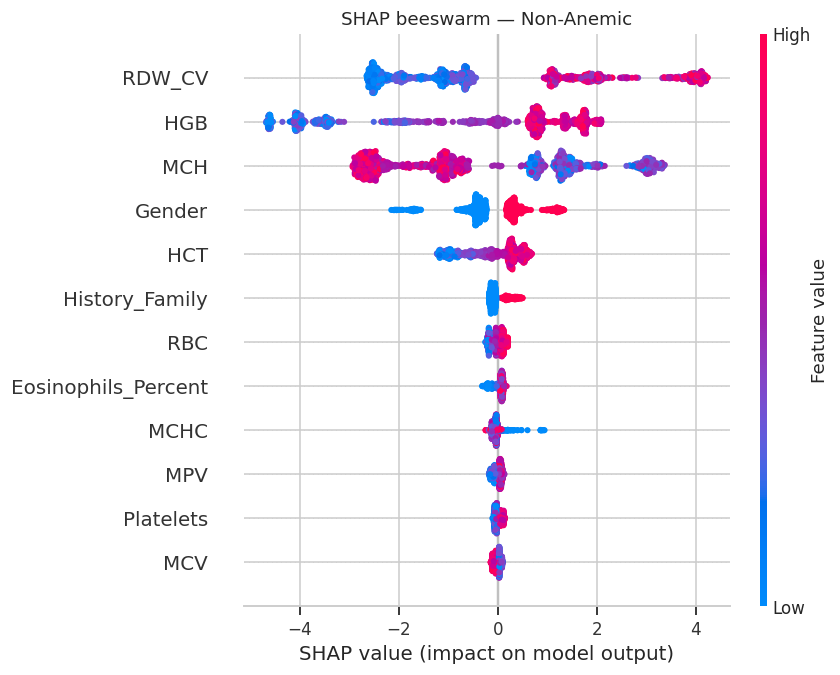

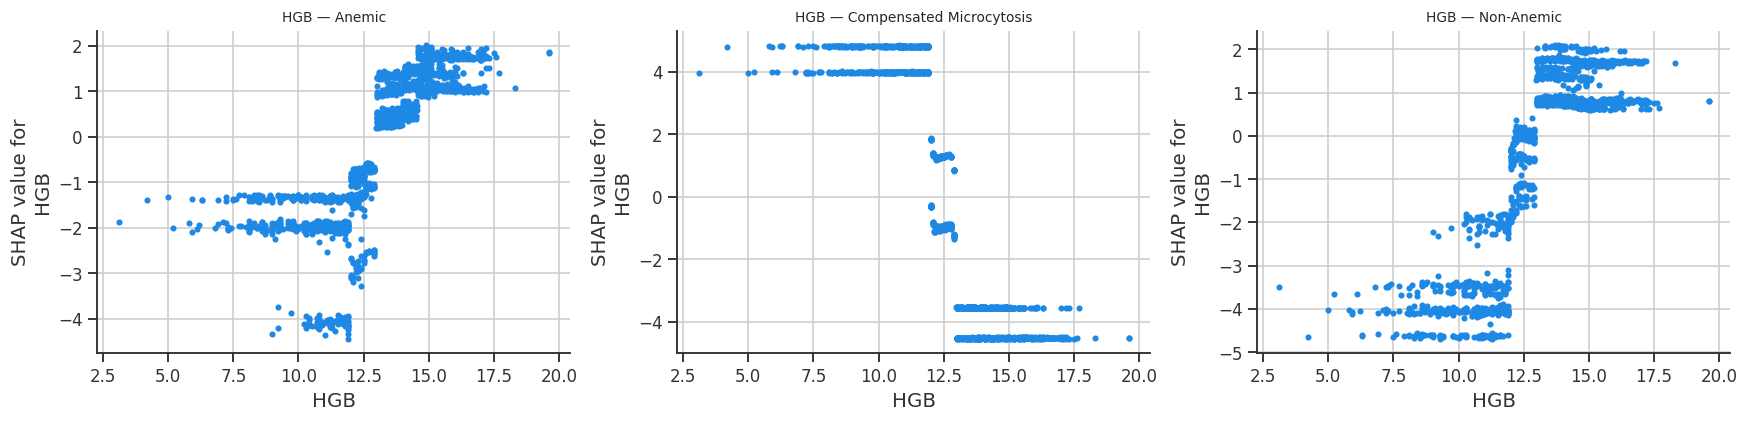

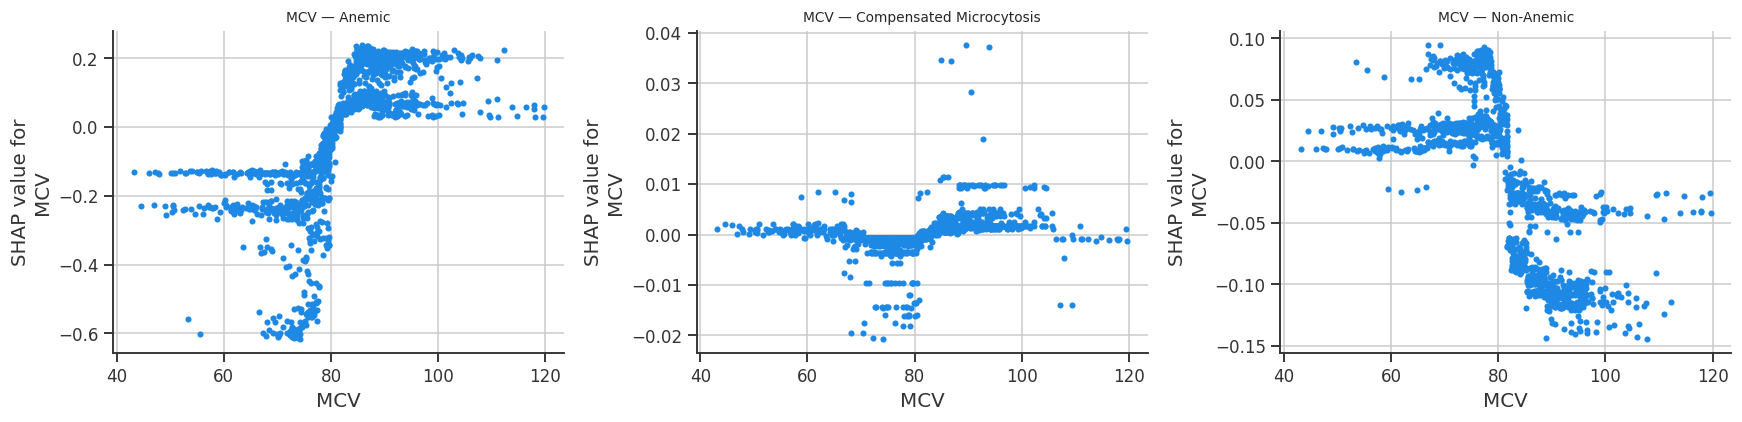

In [27]:
if RUN_SHAP:
    try:
        import shap
        Xs = dfm[FS['ALL features (EXP-20)']]; mdl = make_models(SEED)[PRIMARY]; mdl.fit(Xs, y_all)
        Xi = pd.DataFrame(mdl[:-1].transform(Xs), columns=Xs.columns); est = mdl[-1]
        samp = Xi.sample(min(1500, len(Xi)), random_state=SEED)
        ex = shap.TreeExplainer(est); sv = ex.shap_values(samp)
        sv = np.stack(sv, -1) if isinstance(sv, list) else sv          # (n, features, classes)
        glob_imp = pd.DataFrame(np.abs(sv).mean(0), index=samp.columns, columns=[CLS_SHORT[c] for c in CLASSES]); glob_imp['Global'] = glob_imp.mean(1)
        glob_imp = glob_imp.sort_values('Global', ascending=False); save_table(glob_imp.round(4), 'EXP27_shap_importance')
        glob_imp['Global'].head(15)[::-1].plot.barh(figsize=(7, 5), color='#264653'); plt.title('EXP-27 global mean(|SHAP|)'); save_fig('EXP27_shap_global')
        glob_imp.drop(columns='Global').head(12)[::-1].plot.barh(figsize=(8, 6), color=[PALETTE[c] for c in CLASSES]); plt.title('EXP-27 class-wise mean(|SHAP|)'); save_fig('EXP27_shap_classwise')
        for k, c in enumerate(CLASSES):
            shap.summary_plot(sv[:, :, k], samp, show=False, max_display=12); plt.title(f'SHAP beeswarm — {c}'); save_fig(f'EXP27_beeswarm_{CLS_SHORT[c]}')
        for f in ['HGB', 'MCV']:
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))
            for k, c in enumerate(CLASSES): shap.dependence_plot(f, sv[:, :, k], samp, ax=axes[k], show=False, interaction_index=None); axes[k].set_title(f'{f} — {c}', fontsize=9)
            save_fig(f'EXP27_dependence_{f}')
    except Exception as e: print('SHAP step skipped:', repr(e))

## K. Feature redundancy (EXP-28, EXP-29)

In [28]:
from sklearn.linear_model import LinearRegression
def vif_table(X):
    X = X.copy(); X = X.fillna(X.median()); out = {}
    for c in X.columns:
        others = X.drop(columns=c); r2 = LinearRegression().fit(others, X[c]).score(others, X[c]); out[c] = 1 / (1 - r2) if r2 < .999999 else np.inf
    return pd.Series(out)
NUMF = CBC_ALL + ['Age']
v0 = vif_table(dfm[NUMF]).sort_values(ascending=False); save_table(v0.round(2).to_frame('VIF'), 'EXP28_VIF_all_numeric')
# iterative pruning
keep = list(NUMF)
while True:
    v = vif_table(dfm[keep])
    if v.max() <= VIF_LIMIT: break
    keep.remove(v.idxmax())
dropped = [c for c in NUMF if c not in keep]
print('Dropped for VIF >', VIF_LIMIT, ':', dropped); print('Kept:', keep)
pc = df[NUMF].corr('spearman').abs().where(np.triu(np.ones((len(NUMF),)*2), 1).astype(bool)).stack().sort_values(ascending=False)
save_table(pc[pc > .8].round(3).to_frame('|spearman rho|'), 'EXP28_highly_correlated_pairs')

,VIF
Neutrophils_Percent,57743.51
Lymphocytes_Percent,52091.55
Monocytes_Percent,4421.18
Eosinophils_Percent,1500.62
MCV,735.87
MCH,714.06
HGB,184.56
Basophils_Percent,158.47
HCT,116.92
MCHC,52.57


Dropped for VIF > 10.0 : ['HGB', 'HCT', 'MCV', 'PCT', 'Neutrophils_Percent']
Kept: ['RBC', 'MCH', 'MCHC', 'RDW_CV', 'Platelets', 'MPV', 'WBC', 'Lymphocytes_Percent', 'Monocytes_Percent', 'Eosinophils_Percent', 'Basophils_Percent', 'Age']


,,|spearman rho|
HGB,HCT,0.972
MCV,MCH,0.950
Neutrophils_Percent,Lymphocytes_Percent,0.931
Platelets,PCT,0.922


In [29]:
FS['Redundancy-reduced (EXP-29)'] = keep + QUEST + ['Gender']
FS['Redundancy-reduced, no HGB/MCV (EXP-29b)'] = [c for c in keep if c not in ('HGB', 'MCV')] + QUEST + ['Gender']
rows = []
for fsn in ['ALL features (EXP-20)', 'Redundancy-reduced (EXP-29)', 'ALL minus HGB,MCV (EXP-21/25 combined)', 'Redundancy-reduced, no HGB/MCV (EXP-29b)']:
    for mn in sorted(set([PRIMARY, 'Random Forest', 'Logistic Regression']) & set(MODEL_NAMES)):
        f, _ = run(fsn, mn); rows.append({'feature set': fsn, 'model': mn, 'n_features': len(FS[fsn]), 'Macro-F1': f['Macro-F1'].mean(), 'SD': f['Macro-F1'].std(), 'Balanced Acc': f['Balanced Acc'].mean()})
e29 = pd.DataFrame(rows).set_index(['feature set', 'model']).round(4); save_table(e29, 'EXP29_redundancy_reduced_model')

n_features  \
feature set                              model                             
ALL features (EXP-20)                    Logistic Regression          21   
                                         Random Forest                21   
                                         XGBoost                      21   
Redundancy-reduced (EXP-29)              Logistic Regression          16   
                                         Random Forest                16   
                                         XGBoost                      16   
ALL minus HGB,MCV (EXP-21/25 combined)   Logistic Regression          19   
                                         Random Forest                19   
                                         XGBoost                      19   
Redundancy-reduced, no HGB/MCV (EXP-29b) Logistic Regression          16   
                                         Random Forest                16   
                                         XGBoost                      16   

                                                              Macro-F1  \
feature set                              model                           
ALL features (EXP-20)                    Logistic Regression    0.9238   
                                         Random Forest          0.9941   
                                         XGBoost                0.9988   
Redundancy-reduced (EXP-29)              Logistic Regression    0.8995   
                                         Random Forest          0.9658   
                                         XGBoost                0.9901   
ALL minus HGB,MCV (EXP-21/25 combined)   Logistic Regression    0.9198   
                                         Random Forest          0.9624   
                                         XGBoost                0.9879   
Redundancy-reduced, no HGB/MCV (EXP-29b) Logistic Regression    0.8995   
                                         Random Forest          0.9658   
                                         XGBoost                0.9901   

                                                                  SD  \
feature set                              model                         
ALL features (EXP-20)                    Logistic Regression  0.0111   
                                         Random Forest        0.0035   
                                         XGBoost              0.0011   
Redundancy-reduced (EXP-29)              Logistic Regression  0.0189   
                                         Random Forest        0.0064   
                                         XGBoost              0.0045   
ALL minus HGB,MCV (EXP-21/25 combined)   Logistic Regression  0.0125   
                                         Random Forest        0.0035   
                                         XGBoost              0.0028   
Redundancy-reduced, no HGB/MCV (EXP-29b) Logistic Regression  0.0189   
                                         Random Forest        0.0064   
                                         XGBoost              0.0045   

                                                              Balanced Acc  
feature set                              model                              
ALL features (EXP-20)                    Logistic Regression        0.9238  
                                         Random Forest              0.9941  
                                         XGBoost                    0.9988  
Redundancy-reduced (EXP-29)              Logistic Regression        0.8994  
                                         Random Forest              0.9661  
                                         XGBoost                    0.9901  
ALL minus HGB,MCV (EXP-21/25 combined)   Logistic Regression        0.9198  
                                         Random Forest              0.9627  
                                         XGBoost                    0.9880  
Redundancy-reduced, no HGB/MCV (EXP-29b) Logistic Regression        0.8994  
                           

## L. Robustness (EXP-30, EXP-31)

In [30]:
rows = []
for fsn in ['ALL features (EXP-20)', 'ALL minus HGB,MCV (EXP-21/25 combined)']:
    per_seed = pd.DataFrame([run(fsn, PRIMARY, s)[0].mean() for s in SEEDS], index=SEEDS)
    for m in ['Accuracy', 'Macro-F1', 'Balanced Acc', 'MCC', 'ROC-AUC (macro OVR)']:
        rows.append({'feature set': fsn, 'metric': m, 'mean ± SD over 5 seeds': f'{per_seed[m].mean():.4f} ± {per_seed[m].std():.4f}'})
save_table(pd.DataFrame(rows).set_index(['feature set', 'metric']), 'EXP30_seed_stability')

mean ± SD over 5 seeds
feature set                            metric                                    
ALL features (EXP-20)                  Accuracy                   0.9985 ± 0.0003
                                       Macro-F1                   0.9985 ± 0.0003
                                       Balanced Acc               0.9985 ± 0.0003
                                       MCC                        0.9978 ± 0.0004
                                       ROC-AUC (macro OVR)        0.9999 ± 0.0000
ALL minus HGB,MCV (EXP-21/25 combined) Accuracy                   0.9882 ± 0.0009
                                       Macro-F1                   0.9883 ± 0.0009
                                       Balanced Acc               0.9884 ± 0.0009
                                       MCC                        0.9824 ± 0.0013
                                       ROC-AUC (macro OVR)        0.9997 ± 0.0000

In [31]:
rng = np.random.default_rng(SEED)
def boot_ci(y, P, B=N_BOOT):
    n = len(y); out = {k: [] for k in ['Macro-F1', 'Balanced Acc', 'MCC', 'Macro-AUC']}
    for _ in range(B):
        i = rng.integers(0, n, n); yy, PP = y[i], P[i]
        if len(np.unique(yy)) < 3: continue
        pr = PP.argmax(1)
        out['Macro-F1'].append(f1_score(yy, pr, average='macro')); out['Balanced Acc'].append(balanced_accuracy_score(yy, pr))
        out['MCC'].append(matthews_corrcoef(yy, pr)); out['Macro-AUC'].append(roc_auc_score(yy, PP, multi_class='ovr', average='macro'))
    return out
rows = []
for fsn in ['ALL features (EXP-20)', 'ALL minus HGB,MCV (EXP-21/25 combined)']:
    _, oof = run(fsn, PRIMARY); yb = np.arange(len(y_all)); bt = boot_ci(y_all, oof)
    pt = metrics_from(y_all, oof)
    for k, key in [('Macro-F1', 'Macro-F1'), ('Balanced Acc', 'Balanced Acc'), ('MCC', 'MCC'), ('Macro-AUC', 'ROC-AUC (macro OVR)')]:
        lo, hi = np.percentile(bt[k], [2.5, 97.5]); rows.append({'feature set': fsn, 'metric': k, 'point (pooled OOF)': pt[key], '95% CI low': lo, '95% CI high': hi})
save_table(pd.DataFrame(rows).set_index(['feature set', 'metric']).round(4), 'EXP31_bootstrap_CI')

point (pooled OOF)  \
feature set                            metric                             
ALL features (EXP-20)                  Macro-F1                  0.9988   
                                       Balanced Acc              0.9988   
                                       MCC                       0.9982   
                                       Macro-AUC                 0.9999   
ALL minus HGB,MCV (EXP-21/25 combined) Macro-F1                  0.9879   
                                       Balanced Acc              0.9880   
                                       MCC                       0.9818   
                                       Macro-AUC                 0.9997   

                                                     95% CI low  95% CI high  
feature set                            metric                                 
ALL features (EXP-20)                  Macro-F1          0.9978       0.9996  
                                       Balanced Acc      0.9978       0.9996  
                                       MCC               0.9967       0.9994  
                                       Macro-AUC         0.9998       1.0000  
ALL minus HGB,MCV (EXP-21/25 combined) Macro-F1          0.9848       0.9908  
                                       Balanced Acc      0.9849       0.9909  
                                       MCC               0.9771       0.9863  
                                       Macro-AUC         0.9995       0.9998

## M. Class-specific one-vs-rest performance (EXP-32)

In [32]:
rows = []
for fsn in ['ALL features (EXP-20)', 'ALL minus HGB,MCV (EXP-21/25 combined)']:
    _, oof = run(fsn, PRIMARY); pr = oof.argmax(1); yb = label_binarize(y_all, classes=[0, 1, 2])
    for k, c in enumerate(CLASSES):
        rows.append({'feature set': fsn, 'class': c, 'Precision': precision_score(y_all == k, pr == k), 'Recall': recall_score(y_all == k, pr == k),
                     'F1': f1_score(y_all == k, pr == k), 'ROC-AUC': roc_auc_score(yb[:, k], oof[:, k]), 'PR-AUC': average_precision_score(yb[:, k], oof[:, k])})
e32 = pd.DataFrame(rows).set_index(['feature set', 'class']).round(4); save_table(e32, 'EXP32_one_vs_rest')

Precision  \
feature set                            class                                 
ALL features (EXP-20)                  Anemic                       0.9976   
                                       Compensated Microcytosis     1.0000   
                                       Non-Anemic                   0.9988   
ALL minus HGB,MCV (EXP-21/25 combined) Anemic                       0.9874   
                                       Compensated Microcytosis     0.9889   
                                       Non-Anemic                   0.9873   

                                                                 Recall  \
feature set                            class                              
ALL features (EXP-20)                  Anemic                    0.9988   
                                       Compensated Microcytosis  1.0000   
                                       Non-Anemic                0.9976   
ALL minus HGB,MCV (EXP-21/25 combined) Anemic                    0.9922   
                                       Compensated Microcytosis  0.9792   
                                       Non-Anemic                0.9927   

                                                                     F1  \
feature set                            class                              
ALL features (EXP-20)                  Anemic                    0.9982   
                                       Compensated Microcytosis  1.0000   
                                       Non-Anemic                0.9982   
ALL minus HGB,MCV (EXP-21/25 combined) Anemic                    0.9898   
                                       Compensated Microcytosis  0.9840   
                                       Non-Anemic                0.9900   

                                                                 ROC-AUC  \
feature set                            class                               
ALL features (EXP-20)                  Anemic                     0.9999   
                                       Compensated Microcytosis   1.0000   
                                       Non-Anemic                 0.9999   
ALL minus HGB,MCV (EXP-21/25 combined) Anemic                     0.9997   
                                       Compensated Microcytosis   0.9996   
                                       Non-Anemic                 0.9997   

                                                                 PR-AUC  
feature set                            class                             
ALL features (EXP-20)                  Anemic                    0.9998  
                                       Compensated Microcytosis  1.0000  
                                       Non-Anemic                0.9997  
ALL minus HGB,MCV (EXP-21/25 combined) Anemic                    0.9995  
                                       Compensated Microcytosis  0.9993  
                                       Non-Anemic                0.9994

## N. Boundary analysis (EXP-33)

In [33]:
thr = df.Gender.map(TH)
zones = {'|HGB - T_H| <= 0.5': (df.HGB - thr).abs() <= .5, '|MCV - 80| <= 2': (df.MCV - 80).abs() <= 2,
         '|MCH - 27| <= 0.5 (audit)': (df.MCH - 27).abs() <= .5, '|RDW_CV - 14.5| <= 0.5 (audit)': (df.RDW_CV - 14.5).abs() <= .5}
_, oofA = run('ALL features (EXP-20)', PRIMARY); _, oofB = run('ALL minus HGB,MCV (EXP-21/25 combined)', PRIMARY)
errA, errB = oofA.argmax(1) != y_all, oofB.argmax(1) != y_all
rows = []
for z, m in zones.items():
    vc = df.loc[m, 'Class'].value_counts()
    rows.append({'zone': z, 'n': int(m.sum()), **{f'% {CLS_SHORT[c]}': 100 * vc.get(c, 0) / max(m.sum(), 1) for c in CLASSES},
                 'OOF error % (all features)': 100 * errA[m.values].mean(), 'OOF error % (no HGB/MCV)': 100 * errB[m.values].mean(),
                 'error % outside zone (all)': 100 * errA[~m.values].mean()})
e33 = pd.DataFrame(rows).set_index('zone').round(2); save_table(e33, 'EXP33_boundary_zones')

,n,% Anemic,% CM,% Non-Anemic,OOF error % (all features),OOF error % (no HGB/MCV),error % outside zone (all)
zone,,,,,,,
|HGB - T_H| <= 0.5,908,24.34,39.76,35.90,0.11,0.11,0.12
|MCV - 80| <= 2,851,28.08,30.32,41.60,0.12,0.94,0.12
|MCH - 27| <= 0.5 (audit),666,17.27,31.83,50.90,0.75,1.95,0.02
|RDW_CV - 14.5| <= 0.5 (audit),623,22.79,44.14,33.07,0.16,1.77,0.11


## O. Compensated-Microcytosis phenotype (EXP-34 … EXP-36)

,CM median [IQR],Non-Anemic median [IQR],Mann-Whitney p,Cohen's d,Cliff's delta,p_Holm
variable,,,,,,
HGB,10.90 [9.70-11.80],13.90 [13.14-14.80],0.0,-2.42650,-0.96434,0.0
MCV,76.80 [68.53-83.40],78.96 [75.10-84.89],0.0,-0.42519,-0.20523,0.0
MCH,26.28 [23.24-28.14],26.75 [25.70-28.83],0.0,-0.44343,-0.20993,0.0
RBC,4.22 [3.81-4.58],5.15 [4.80-5.50],0.0,-1.63357,-0.77953,0.0
RDW_CV,14.31 [12.91-16.04],15.66 [13.58-17.96],0.0,-0.35964,-0.22752,0.0
HCT,32.14 [28.43-34.87],40.94 [38.52-43.58],0.0,-2.31705,-0.94256,0.0


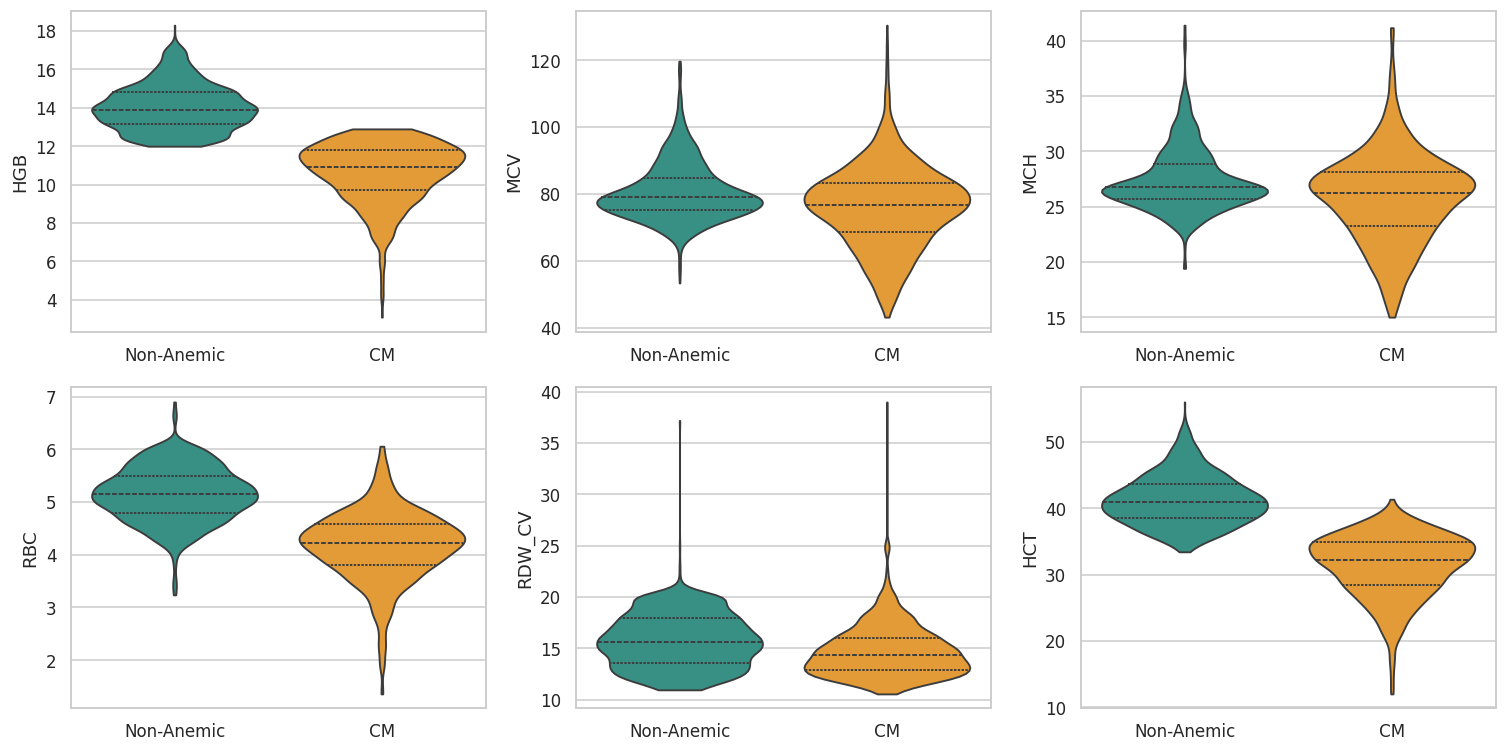

In [34]:
CMV = ['HGB', 'MCV', 'MCH', 'RBC', 'RDW_CV', 'HCT']; rows = []
a, b = 'Compensated Microcytosis', 'Non-Anemic'
for v in CMV:
    x, y_ = df.loc[df.Class == a, v].dropna(), df.loc[df.Class == b, v].dropna()
    rows.append({'variable': v, 'CM median [IQR]': f'{x.median():.2f} [{x.quantile(.25):.2f}-{x.quantile(.75):.2f}]', 'Non-Anemic median [IQR]': f'{y_.median():.2f} [{y_.quantile(.25):.2f}-{y_.quantile(.75):.2f}]',
                 'Mann-Whitney p': stats.mannwhitneyu(x, y_).pvalue, "Cohen's d": cohens_d(x, y_), "Cliff's delta": cliffs_delta(x, y_)})
e34 = pd.DataFrame(rows).set_index('variable'); e34['p_Holm'] = multipletests(e34['Mann-Whitney p'], method='holm')[1]; save_table(e34.round(5), 'EXP34_CM_vs_NonAnemic')
sub = df[df.Class.isin([a, b])]; fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, v in zip(axes.ravel(), CMV): sns.violinplot(data=sub, x='Class', y=v, order=[b, a], palette=PALETTE, ax=ax, cut=0, inner='quartile'); ax.set_xticklabels(['Non-Anemic', 'CM']); ax.set_xlabel('')
save_fig('EXP34_CM_vs_NonAnemic_violins')

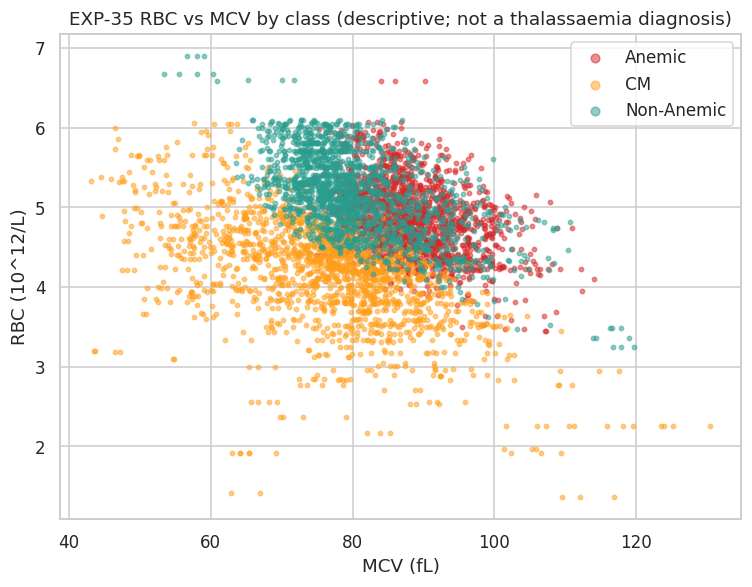

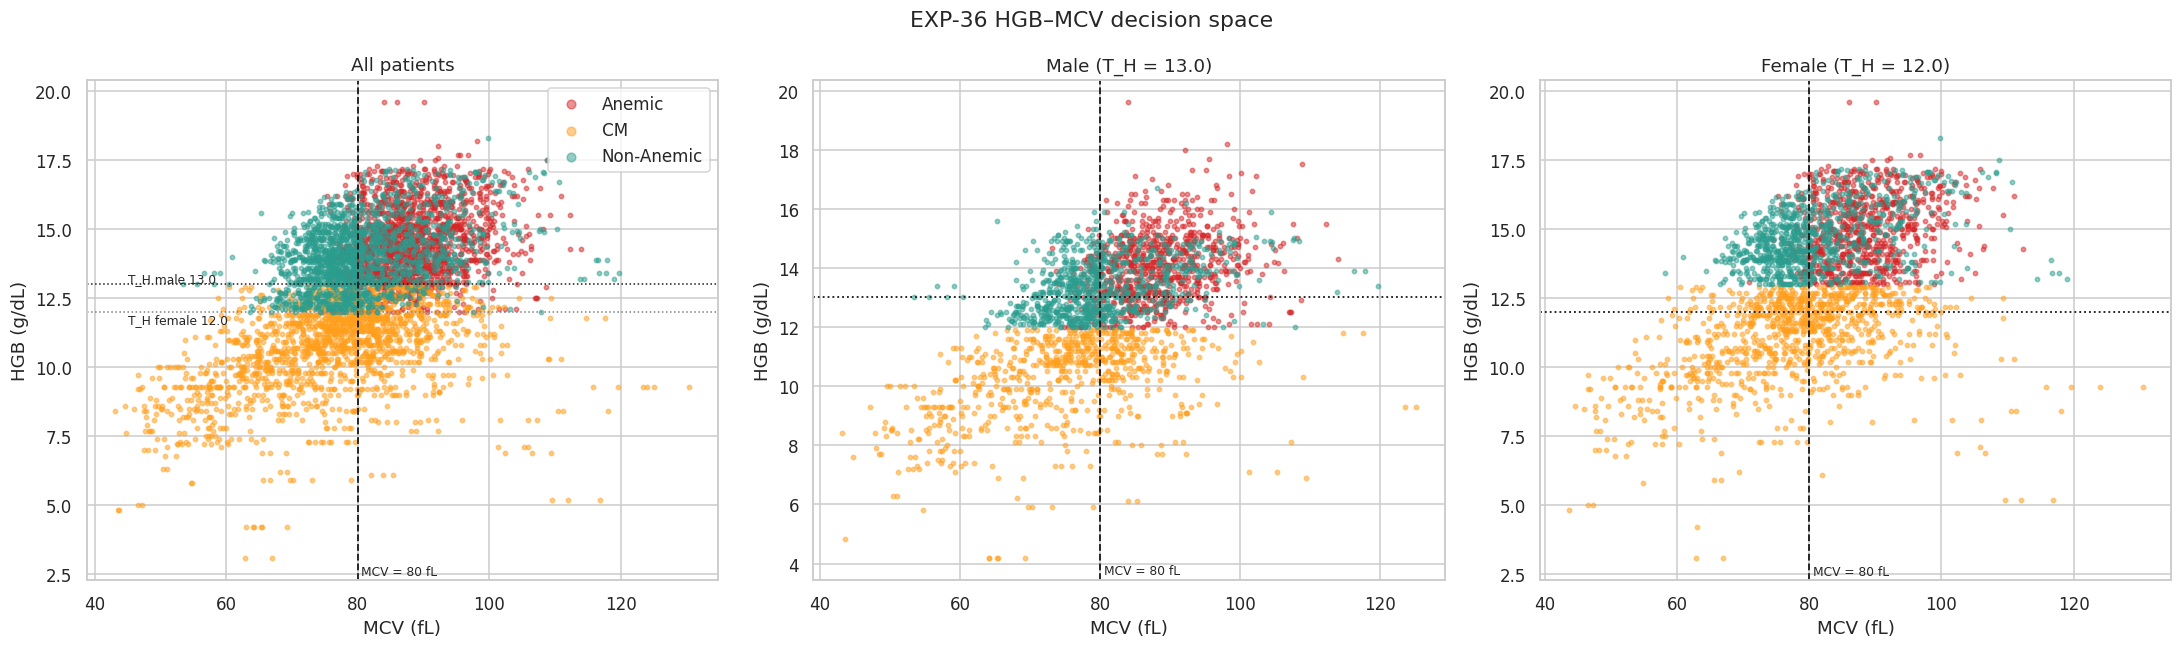

In [35]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for c in CLASSES: s = df[df.Class == c]; ax.scatter(s.MCV, s.RBC, s=8, alpha=.5, c=PALETTE[c], label=CLS_SHORT[c])
ax.set_xlabel('MCV (fL)'); ax.set_ylabel('RBC (10^12/L)'); ax.legend(markerscale=2); ax.set_title('EXP-35 RBC vs MCV by class (descriptive; not a thalassaemia diagnosis)'); save_fig('EXP35_RBC_vs_MCV')
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
for ax, (t, s) in zip(axes, [('All patients', df), ('Male (T_H = 13.0)', df[df.Gender == 'Male']), ('Female (T_H = 12.0)', df[df.Gender == 'Female'])]):
    for c in CLASSES: q = s[s.Class == c]; ax.scatter(q.MCV, q.HGB, s=8, alpha=.5, c=PALETTE[c], label=CLS_SHORT[c])
    ax.axvline(80, c='k', ls='--', lw=1.2); ax.text(80.5, ax.get_ylim()[0] + .2, 'MCV = 80 fL', fontsize=8)
    if t.startswith('All'): ax.axhline(13.0, c='k', ls=':', lw=1); ax.axhline(12.0, c='grey', ls=':', lw=1); ax.text(45, 13.1, 'T_H male 13.0', fontsize=8); ax.text(45, 11.6, 'T_H female 12.0', fontsize=8)
    else: ax.axhline(TH['Male' if 'Male' in t else 'Female'], c='k', ls=':', lw=1.2)
    ax.set_xlabel('MCV (fL)'); ax.set_ylabel('HGB (g/dL)'); ax.set_title(t)
axes[0].legend(markerscale=2); plt.suptitle('EXP-36 HGB–MCV decision space'); save_fig('EXP36_HGB_MCV_decision_space')

## P. Questionnaire utility (EXP-37 … EXP-39)

In [36]:
def woolf_or(a, b, c, d):   # 2x2 [[a,b],[c,d]] with 0.5 continuity if needed
    if min(a, b, c, d) == 0: a, b, c, d = a + .5, b + .5, c + .5, d + .5
    o = (a * d) / (b * c); se = np.sqrt(1/a + 1/b + 1/c + 1/d); return o, o * np.exp(-1.96 * se), o * np.exp(1.96 * se)
def questionnaire_assoc(v, tag):
    print(f'--- {tag}: {v} ---'); ct = pd.crosstab(df.Class, df[v]).reindex(CLASSES); chi2, p, dof, _ = stats.chi2_contingency(ct)
    prev = pd.DataFrame({'n': ct.sum(1), 'n Yes': ct['Yes'], 'prevalence % Yes': (100 * ct['Yes'] / ct.sum(1)).round(2)})
    display(prev); print(f'chi2={chi2:.3f}, dof={dof}, p={p:.4g}, Cramer V={cramers_v(ct):.4f}')
    rows, ps = [], []
    for a, b in [('Anemic', 'Non-Anemic'), ('Compensated Microcytosis', 'Non-Anemic'), ('Anemic', 'Compensated Microcytosis')]:
        s = df[df.Class.isin([a, b])]; t = pd.crosstab(s.Class, s[v]).reindex([a, b])
        o, lo, hi = woolf_or(t.loc[a, 'Yes'], t.loc[a, 'No'], t.loc[b, 'Yes'], t.loc[b, 'No']); pf = stats.fisher_exact(t.values)[1]; ps.append(pf)
        rows.append({'comparison': f'{CLS_SHORT[a]} vs {CLS_SHORT[b]}', 'OR': o, '95% CI low': lo, '95% CI high': hi, 'Fisher p': pf})
    r = pd.DataFrame(rows).set_index('comparison'); r['p_Holm'] = multipletests(ps, method='holm')[1]; save_table(r.round(4), f'{tag}_{v}_odds_ratios')
    prev.to_csv(f'{TAB}/{tag}_{v}_prevalence.csv')
questionnaire_assoc('History_Anemia', 'EXP37'); questionnaire_assoc('History_Family', 'EXP38')
print('\nNote: History_Family is family history of anemia (broad) - do not describe it as hereditary-hemoglobinopathy history. Associations are not causal.')
questionnaire_assoc('Substance_Use', 'EXP39')

--- EXP37: History_Anemia ---


,n,n Yes,prevalence % Yes
Class,,,
Anemic,1664,362,21.75
Compensated Microcytosis,1732,259,14.95
Non-Anemic,1641,534,32.54


chi2=149.427, dof=2, p=3.567e-33, Cramer V=0.1722


,OR,95% CI low,95% CI high,Fisher p,p_Holm
comparison,,,,,
Anemic vs Non-Anemic,0.5764,0.4933,0.6734,0.0,0.0
CM vs Non-Anemic,0.3645,0.3082,0.4310,0.0,0.0
Anemic vs CM,1.5813,1.3260,1.8857,0.0,0.0


--- EXP38: History_Family ---


...

,OR,95% CI low,95% CI high,Fisher p,p_Holm
comparison,,,,,
Anemic vs Non-Anemic,0.7197,0.6155,0.8416,0.0,0.0
CM vs Non-Anemic,0.4467,0.3775,0.5286,0.0,0.0
Anemic vs CM,1.6112,1.3546,1.9163,0.0,0.0



Note: History_Family is family history of anemia (broad) - do not describe it as hereditary-hemoglobinopathy history. Associations are not causal.
--- EXP39: Substance_Use ---


,n,n Yes,prevalence % Yes
Class,,,
Anemic,1664,378,22.72
Compensated Microcytosis,1732,183,10.57
Non-Anemic,1641,506,30.83


chi2=210.844, dof=2, p=1.644e-46, Cramer V=0.2046


,OR,95% CI low,95% CI high,Fisher p,p_Holm
comparison,,,,,
Anemic vs Non-Anemic,0.6593,0.5645,0.7701,0.0,0.0
CM vs Non-Anemic,0.2650,0.2201,0.3190,0.0,0.0
Anemic vs CM,2.4880,2.0547,3.0127,0.0,0.0


## Q. Multi-centre analyses (EXP-40, EXP-41)

In [37]:
site_cols = [c for c in raw.columns if re.search(r'hosp|site|cent(er|re)|source|origin|institution|centre', c, re.I)]
if not site_cols:
    print('No hospital/source identifier is present in the released CSV -> EXP-40 and EXP-41 are NOT run (source labels must not be reconstructed).')
    note('EXP-40/41 skipped: released CSV has no hospital/source column')
else:
    S = site_cols[0]; print('Using site column:', S)
    save_table(df.groupby(S).agg(n=('PID', 'size'), age=('Age', 'mean'), male_pct=('Gender', lambda x: 100*(x == 'Male').mean()), HGB=('HGB', 'mean'), MCV=('MCV', 'mean')).round(2), 'EXP40_hospital_wise')
    save_table(pd.crosstab(df[S], df.Class, normalize='index').mul(100).round(1), 'EXP40_hospital_class_dist')
    rows = []
    for h in df[S].unique():
        te = (df[S] == h).values; m = make_models(SEED)[PRIMARY].fit(dfm.loc[~te, FS['ALL features (EXP-20)']], y_all[~te])
        P = m.predict_proba(dfm.loc[te, FS['ALL features (EXP-20)']]); rows.append({'held-out site': h, 'n': te.sum(), **metrics_from(y_all[te], P)})
    save_table(pd.DataFrame(rows).set_index('held-out site').round(4), 'EXP41_leave_one_hospital_out')

No hospital/source identifier is present in the released CSV -> EXP-40 and EXP-41 are NOT run (source labels must not be reconstructed).
  >> EXP-40/41 skipped: released CSV has no hospital/source column


## R. Subgroup robustness (EXP-42, EXP-43)
Pooled out-of-fold predictions (5-fold CV) are evaluated inside each subgroup.

In [38]:
def subgroup_eval(mask, name, oof):
    m = np.asarray(mask); y, pr = y_all[m], oof[m].argmax(1)
    if len(y) < 50: return {'group': name, 'n': int(m.sum()), 'note': 'n<50 - not evaluated'}
    r = {'group': name, 'n': int(m.sum()), 'Macro-F1': f1_score(y, pr, average='macro'), 'Balanced Acc': balanced_accuracy_score(y, pr)}
    rec = recall_score(y, pr, labels=[0, 1, 2], average=None, zero_division=0)
    for k, c in enumerate(CLASSES): r[f'Recall {CLS_SHORT[c]}'] = rec[k]; r[f'n {CLS_SHORT[c]}'] = int((y == k).sum())
    return r
age_bins = pd.cut(df.Age, [-1, 17, 30, 45, 60, 200], labels=['<18', '18-30', '31-45', '46-60', '>60'])
for fsn, tag in [('ALL features (EXP-20)', 'all features'), ('ALL minus HGB,MCV (EXP-21/25 combined)', 'no HGB/MCV')]:
    _, oof = run(fsn, PRIMARY)
    e42 = pd.DataFrame([subgroup_eval(df.Gender == g, g, oof) for g in ['Male', 'Female']]).set_index('group').round(4); print(f'EXP-42 sex-stratified ({tag})'); save_table(e42, f'EXP42_sex_{tag.replace(" ","_").replace("/","")}')
    e43 = pd.DataFrame([subgroup_eval(age_bins == g, str(g), oof) for g in age_bins.cat.categories]).set_index('group').round(4); print(f'EXP-43 age groups ({tag})'); save_table(e43, f'EXP43_age_{tag.replace(" ","_").replace("/","")}')

EXP-42 sex-stratified (all features)


,n,Macro-F1,Balanced Acc,Recall Anemic,n Anemic,Recall CM,n CM,Recall Non-Anemic,n Non-Anemic
group,,,,,,,,,
Male,2369,0.9988,0.9988,1.0000,819,1.0,728,0.9964,822
Female,2668,0.9988,0.9988,0.9976,845,1.0,1004,0.9988,819


EXP-43 age groups (all features)


,n,Macro-F1,Balanced Acc,Recall Anemic,n Anemic,Recall CM,n CM,Recall Non-Anemic,n Non-Anemic
group,,,,,,,,,
<18,95,1.0000,1.0000,1.0000,38,1.0,33,1.0000,24
18-30,1032,0.9990,0.9990,0.9970,335,1.0,377,1.0000,320
31-45,1220,0.9976,0.9975,1.0000,413,1.0,400,0.9926,407
46-60,1227,0.9983,0.9983,0.9976,419,1.0,420,0.9974,388
>60,1463,1.0000,1.0000,1.0000,459,1.0,502,1.0000,502


EXP-42 sex-stratified (no HGB/MCV)


,n,Macro-F1,Balanced Acc,Recall Anemic,n Anemic,Recall CM,n CM,Recall Non-Anemic,n Non-Anemic
group,,,,,,,,,
Male,2369,0.9893,0.9893,0.9927,819,0.9849,728,0.9903,822
Female,2668,0.9867,0.9873,0.9917,845,0.9751,1004,0.9951,819


EXP-43 age groups (no HGB/MCV)


,n,Macro-F1,Balanced Acc,Recall Anemic,n Anemic,Recall CM,n CM,Recall Non-Anemic,n Non-Anemic
group,,,,,,,,,
<18,95,0.9879,0.9861,1.0000,38,1.0000,33,0.9583,24
18-30,1032,0.9904,0.9906,0.9881,335,0.9867,377,0.9969,320
31-45,1220,0.9926,0.9926,0.9952,413,0.9900,400,0.9926,407
46-60,1227,0.9813,0.9814,0.9905,419,0.9667,420,0.9871,388
>60,1463,0.9877,0.9879,0.9935,459,0.9741,502,0.9960,502


## S. Visualisation suite (EXP-44 … EXP-50)

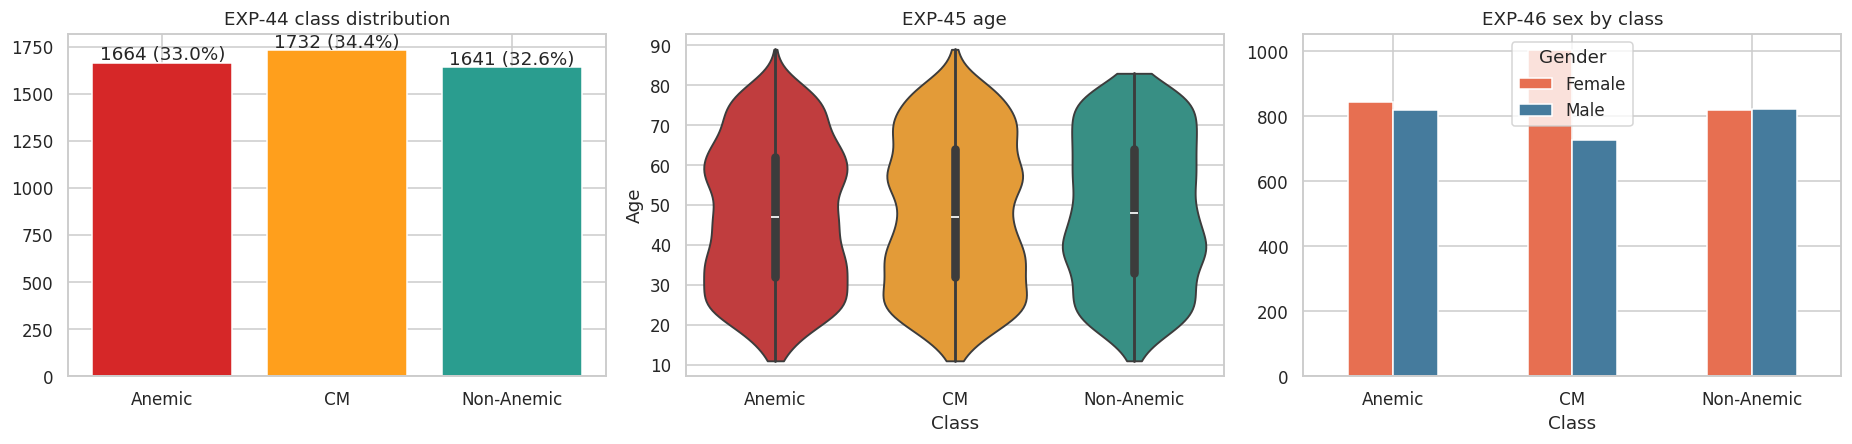

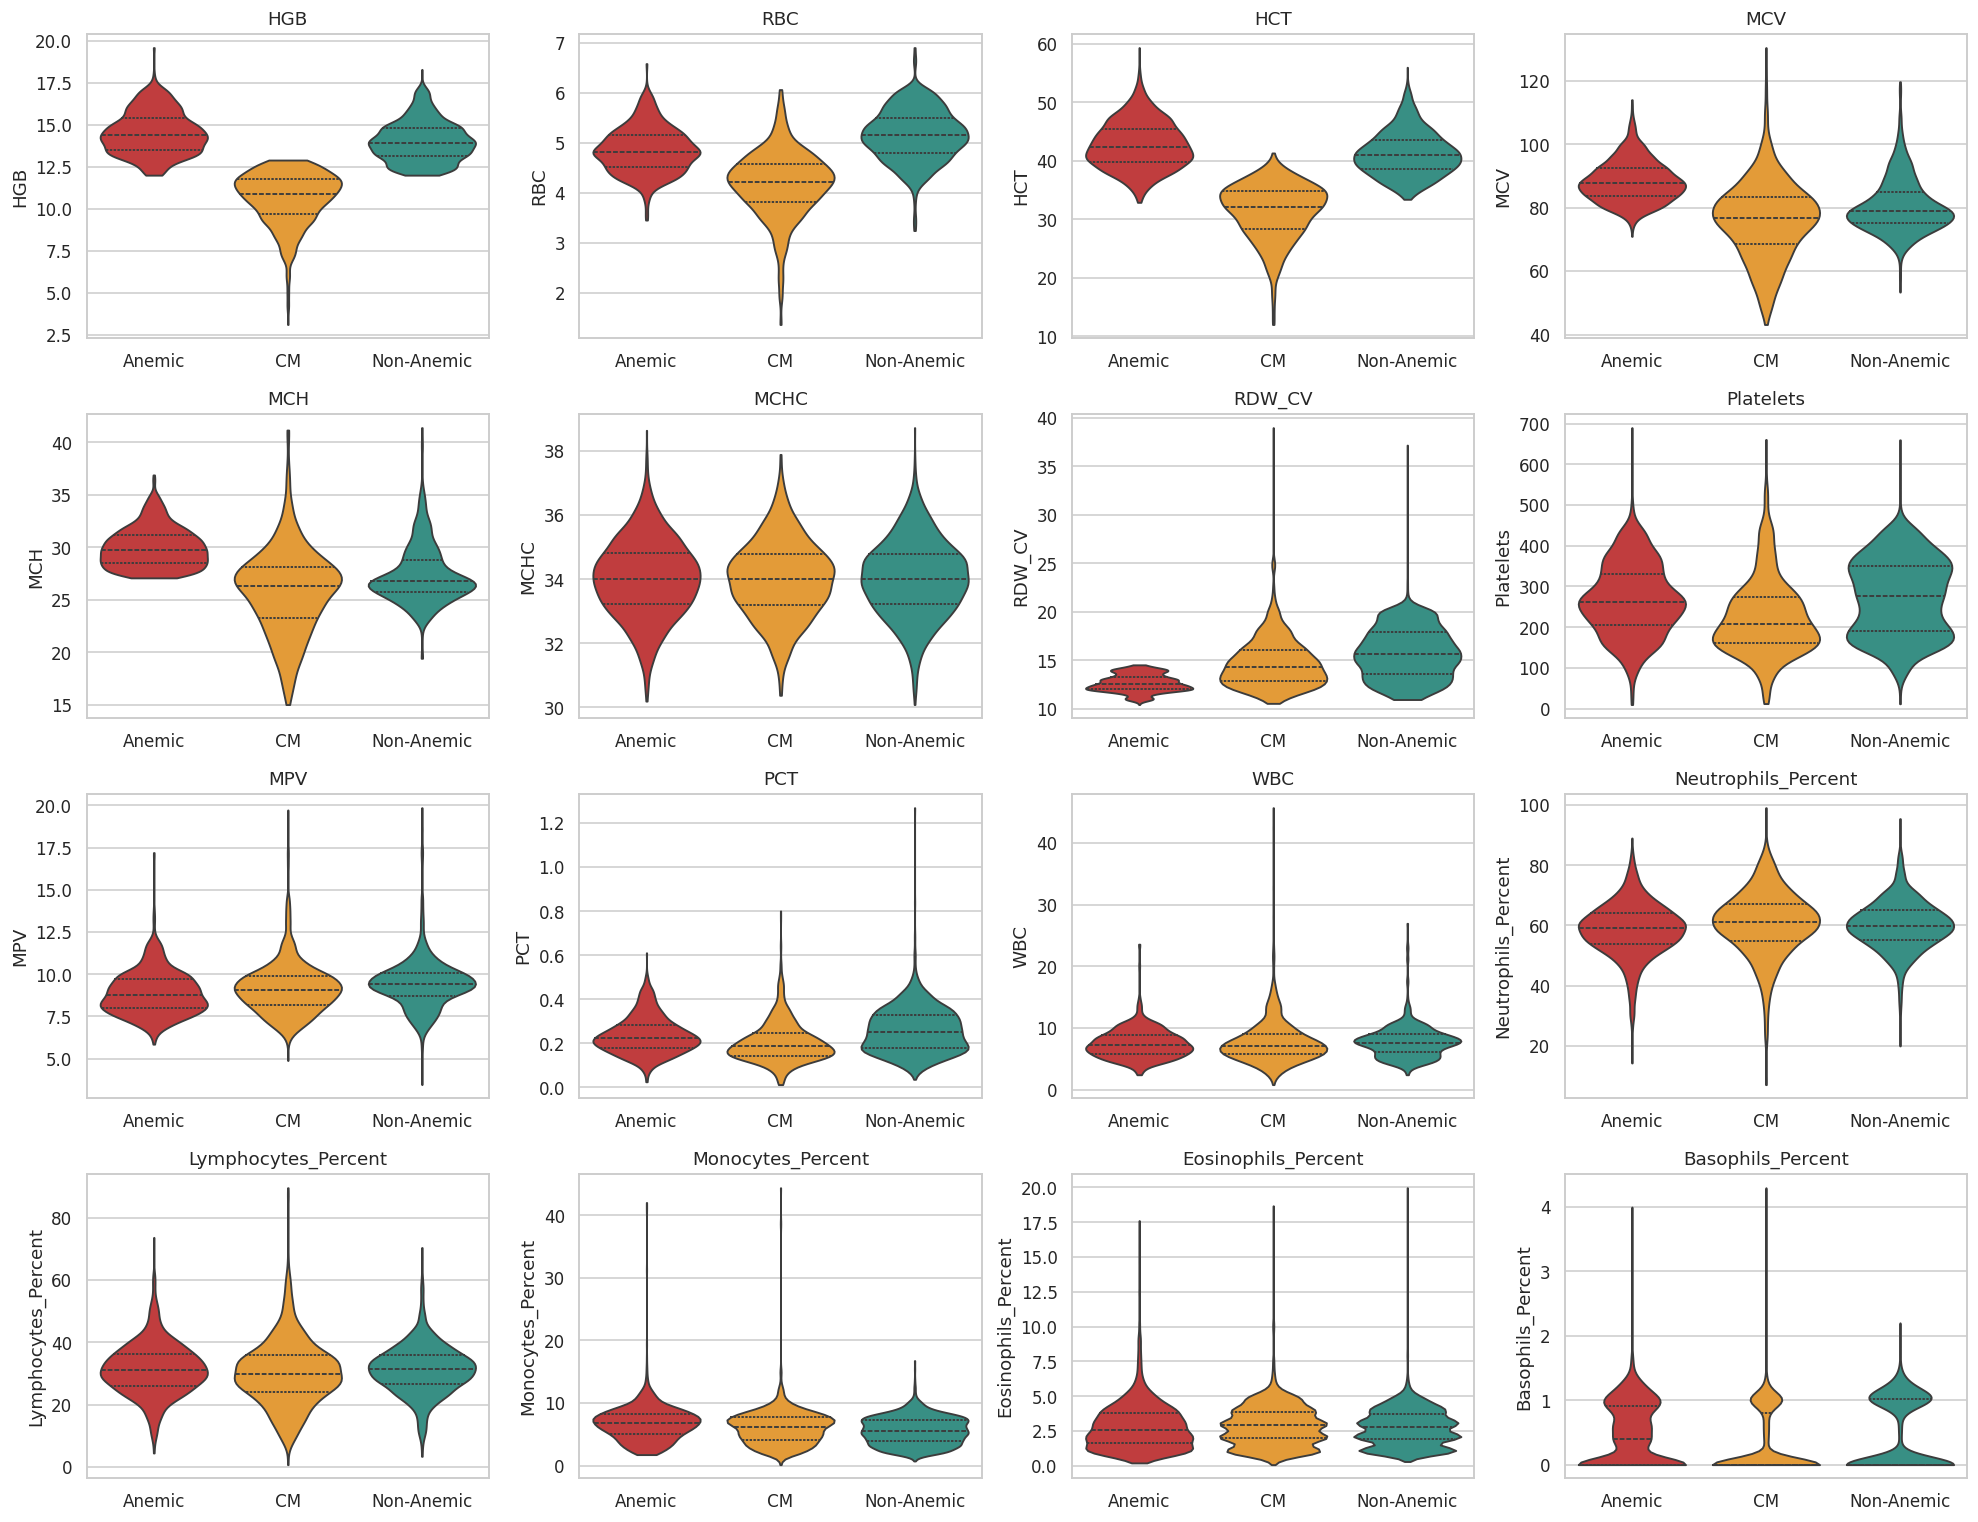

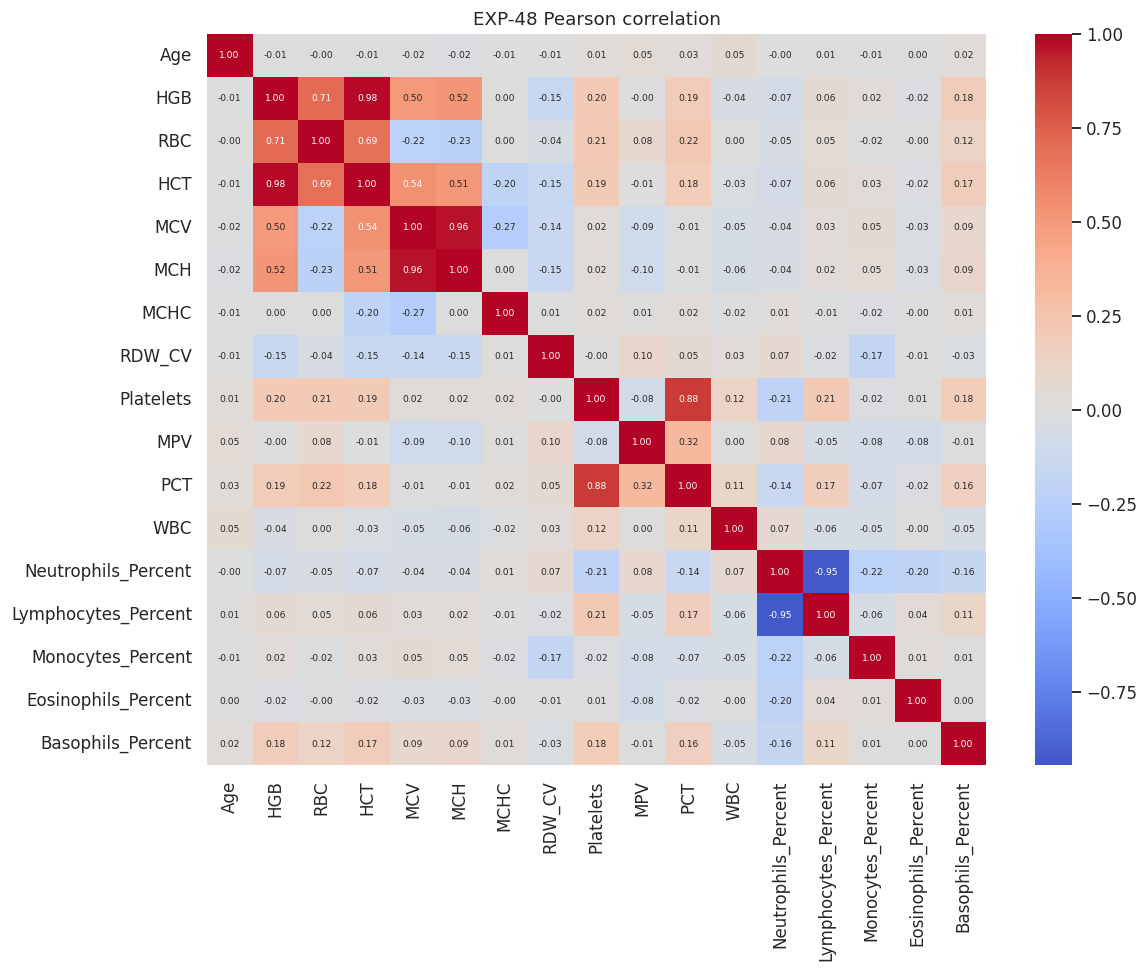

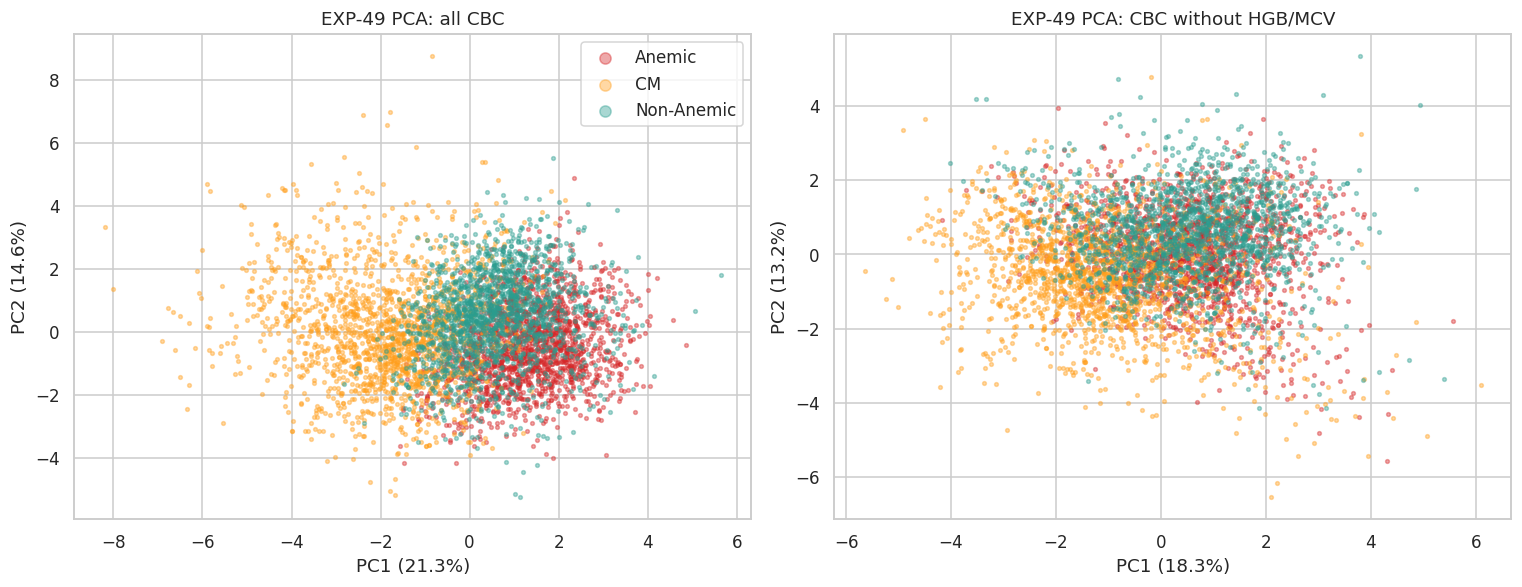

In [39]:
# EXP-44 class distribution, EXP-45 age, EXP-46 sex
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
vc = df.Class.value_counts().reindex(CLASSES); ax[0].bar([CLS_SHORT[c] for c in CLASSES], vc.values, color=[PALETTE[c] for c in CLASSES])
for i, v in enumerate(vc.values): ax[0].text(i, v + 15, f'{v} ({100*v/len(df):.1f}%)', ha='center')
ax[0].set_title('EXP-44 class distribution'); sns.violinplot(data=df, x='Class', y='Age', order=CLASSES, palette=PALETTE, ax=ax[1], cut=0); ax[1].set_xticklabels([CLS_SHORT[c] for c in CLASSES]); ax[1].set_title('EXP-45 age')
pd.crosstab(df.Class, df.Gender).reindex(CLASSES).plot.bar(ax=ax[2], color=['#e76f51', '#457b9d']); ax[2].set_xticklabels([CLS_SHORT[c] for c in CLASSES], rotation=0); ax[2].set_title('EXP-46 sex by class')
save_fig('EXP44_46_class_age_sex')
# EXP-47 CBC violins (cleaned)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, c in zip(axes.ravel(), CBC_ALL): sns.violinplot(data=df, x='Class', y=c, order=CLASSES, palette=PALETTE, ax=ax, cut=0, inner='quartile'); ax.set_xticklabels([CLS_SHORT[x] for x in CLASSES]); ax.set_xlabel(''); ax.set_title(c)
save_fig('EXP47_CBC_violins')
# EXP-48 correlation (already in EXP-10)  -> reuse
plt.figure(figsize=(11, 9)); sns.heatmap(pear, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 6}); plt.title('EXP-48 Pearson correlation'); save_fig('EXP48_correlation')
# EXP-49 PCA
from sklearn.decomposition import PCA
def pca_plot(cols, ax, title):
    Xp = StandardScaler().fit_transform(df[cols].fillna(df[cols].median())); pc = PCA(2, random_state=SEED).fit(Xp); Z = pc.transform(Xp)
    for c in CLASSES: m = (df.Class == c).values; ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=.4, c=PALETTE[c], label=CLS_SHORT[c])
    ax.set_xlabel(f'PC1 ({100*pc.explained_variance_ratio_[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({100*pc.explained_variance_ratio_[1]:.1f}%)'); ax.set_title(title)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5)); pca_plot(CBC_ALL, axes[0], 'EXP-49 PCA: all CBC'); pca_plot(CBC_X, axes[1], 'EXP-49 PCA: CBC without HGB/MCV'); axes[0].legend(markerscale=3)
save_fig('EXP49_PCA')

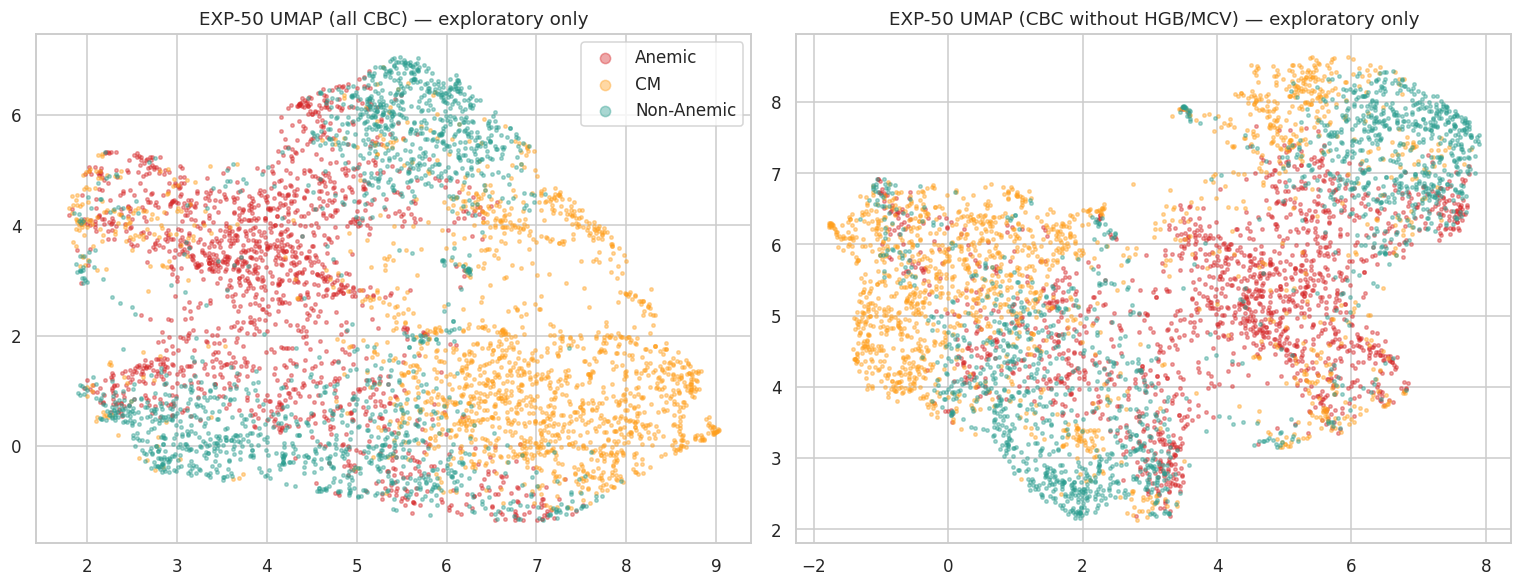

In [40]:
# EXP-50 UMAP (exploratory only)
if RUN_UMAP:
    try:
        import umap
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
        for ax, cols, t in [(axes[0], CBC_ALL, 'all CBC'), (axes[1], CBC_X, 'CBC without HGB/MCV')]:
            Xp = StandardScaler().fit_transform(df[cols].fillna(df[cols].median())); Z = umap.UMAP(n_neighbors=30, min_dist=.1, random_state=SEED).fit_transform(Xp)
            for c in CLASSES: m = (df.Class == c).values; ax.scatter(Z[m, 0], Z[m, 1], s=5, alpha=.4, c=PALETTE[c], label=CLS_SHORT[c])
            ax.set_title(f'EXP-50 UMAP ({t}) — exploratory only')
        axes[0].legend(markerscale=3); save_fig('EXP50_UMAP')
    except Exception as e: print('UMAP skipped:', repr(e))

## T. Reproducibility package (EXP-51) and automatic findings summary

In [41]:
import sklearn, scipy, matplotlib
pk = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__, 'scikit-learn': sklearn.__version__,
      'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__}
for m in ['xgboost', 'lightgbm', 'catboost', 'shap', 'scikit_posthocs', 'statsmodels', 'umap']:
    try: pk[m] = __import__(m).__version__
    except Exception: pk[m] = 'n/a'
manifest = {'created': datetime.now().isoformat(timespec='seconds'), 'data_file': os.path.basename(DATA_PATH), 'data_sha256': DATA_SHA256,
            'n_records': int(len(raw)), 'seed': SEED, 'seeds_EXP30': SEEDS, 'cv_folds': N_SPLITS, 'n_bootstrap': N_BOOT, 'primary_model': PRIMARY,
            'HGB_thresholds': TH, 'implausible_values_set_to_NaN': CLEAN_IMPLAUSIBLE, 'packages': pk}
json.dump(manifest, open(f'{OUT}/run_manifest.json', 'w'), indent=2)
open(f'{OUT}/requirements.txt', 'w').write('\n'.join(f'{k}=={v}' for k, v in pk.items() if k != 'python' and v != 'n/a'))
with open(f'{OUT}/findings.md', 'w') as f:
    f.write('# Automatic findings / flags\n\n' + '\n'.join(f'- {x}' for x in FINDINGS))
print('=' * 90); print('AUTOMATIC FINDINGS - resolve these before finalising the manuscript'); print('=' * 90)
for i, x in enumerate(FINDINGS, 1): print(f'{i:2d}. {x}')
shutil.make_archive(f'{OUT}_bundle', 'zip', OUT); print('\nAll outputs zipped ->', f'{OUT}_bundle.zip')
# if IN_COLAB: from google.colab import files; files.download(f'{OUT}_bundle.zip')

AUTOMATIC FINDINGS - resolve these before finalising the manuscript
 1. EXP-01: Added synthetic PID column as it was missing from the data.
 2. EXP-01: Dropped extraneous ESR column not present in the expected schema.
 3. Implausible values by variable: MPV=16, PCT=12, RDW_CV=5, HCT=2
 4. Age range 11-89: 95 patients are <18 y (check adult-cohort claim / age-range statement)
 5. EXP-03: Near-duplicate numeric profiles (nearest-neighbour z-distance < 0.05) = 16
 6. EXP-11: WHO thresholds (13.0/12.0 g/dL) are NOT consistent with released Anemic labels - define T_H explicitly
 7. EXP-11: the MCV<80 rule reproduces only 18.07% of released labels (4127 disagreements; kappa=-0.225); HGB split is 35.72% exact
 8. EXP-11b: among HGB>=T_H, released CM labels are far better explained by 'MCH < t' (61.9%) than by MCV<80 (53.0%). The paper's label definition must match the data.
 9. Leakage-aware (XGBoost): Macro-F1 all features 0.999 | HGB+MCV only 0.776 | without HGB/MCV 0.988 | CBC-only 0.938 |

In [42]:
from google.colab import files; files.download(f'{OUT}_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>